In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('laptop_price - dataset.csv')

print("First 10 Rows:")
print(df.head(10))

# Explanation:
# selected the Laptop Price dataset because laptop prices depend on several hardware specifications such as RAM, processor, storage, screen size, and weight. 
# These features make it suitable for regression analysis.
# The target variable is Price (Euro), which is a continuous numerical value. 
# By analyzing the relationship between laptop specifications and price, we can build a model to predict laptop prices accurately. 
# This dataset is useful for understanding feature importance and practicing data preprocessing techniques.

First 10 Rows:
  Company          Product   TypeName  Inches  \
0   Apple      MacBook Pro  Ultrabook    13.3   
1   Apple      Macbook Air  Ultrabook    13.3   
2      HP           250 G6   Notebook    15.6   
3   Apple      MacBook Pro  Ultrabook    15.4   
4   Apple      MacBook Pro  Ultrabook    13.3   
5    Acer         Aspire 3   Notebook    15.6   
6   Apple      MacBook Pro  Ultrabook    15.4   
7   Apple      Macbook Air  Ultrabook    13.3   
8    Asus  ZenBook UX430UN  Ultrabook    14.0   
9    Acer          Swift 3  Ultrabook    14.0   

                     ScreenResolution CPU_Company        CPU_Type  \
0  IPS Panel Retina Display 2560x1600       Intel         Core i5   
1                            1440x900       Intel         Core i5   
2                   Full HD 1920x1080       Intel   Core i5 7200U   
3  IPS Panel Retina Display 2880x1800       Intel         Core i7   
4  IPS Panel Retina Display 2560x1600       Intel         Core i5   
5                            13

In [2]:
print("Missing Values in Each Columns:")
print(df.isnull().sum())

print("\nPercentage of each column for missing value:")
print(df.isnull().sum()/len(df)*100)

# Missing values
missing = df.isnull().sum()

# Missing percentage
missing_percent = (missing / len(df)) * 100

print("\nMissing Values:")
print(missing)

print("\nMissing Percentage")
print(missing_percent)

# Fill missing values (if any)

# Numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].mean())

# Categorical columns
cat_cols = df.select_dtypes(include='str').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0])

# Duplicate rows
print("Duplicate Rows =", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

# Observations:
# Checked all columns for missing values.
# Missing percentage was calculated.
# Numeric missing values were replaced with the column mean.
# Categorical missing values were replaced with the mode.
# Duplicate rows were checked and removed.

Missing Values in Each Columns:
Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

Percentage of each column for missing value:
Company                0.0
Product                0.0
TypeName               0.0
Inches                 0.0
ScreenResolution       0.0
CPU_Company            0.0
CPU_Type               0.0
CPU_Frequency (GHz)    0.0
RAM (GB)               0.0
Memory                 0.0
GPU_Company            0.0
GPU_Type               0.0
OpSys                  0.0
Weight (kg)            0.0
Price (Euro)           0.0
dtype: float64

Missing Values:
Company                0
Product                0
TypeName               0
Inches                

In [3]:
print("Stastical Summary:")
print(df.describe())

# Target Variable Statistics
print("\nMinimum Price =", df["Price (Euro)"].min())
print("Maximum Price =", df["Price (Euro)"].max())
print("Mean Price =", df["Price (Euro)"].mean())
print("Median Price =", df["Price (Euro)"].median())

Stastical Summary:
            Inches  CPU_Frequency (GHz)     RAM (GB)  Weight (kg)  \
count  1275.000000          1275.000000  1275.000000  1275.000000   
mean     15.022902             2.302980     8.440784     2.040525   
std       1.429470             0.503846     5.097809     0.669196   
min      10.100000             0.900000     2.000000     0.690000   
25%      14.000000             2.000000     4.000000     1.500000   
50%      15.600000             2.500000     8.000000     2.040000   
75%      15.600000             2.700000     8.000000     2.310000   
max      18.400000             3.600000    64.000000     4.700000   

       Price (Euro)  
count   1275.000000  
mean    1134.969059  
std      700.752504  
min      174.000000  
25%      609.000000  
50%      989.000000  
75%     1496.500000  
max     6099.000000  

Minimum Price = 174.0
Maximum Price = 6099.0
Mean Price = 1134.9690588235292
Median Price = 989.0


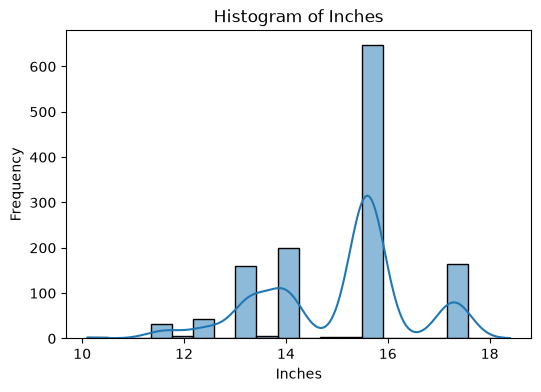

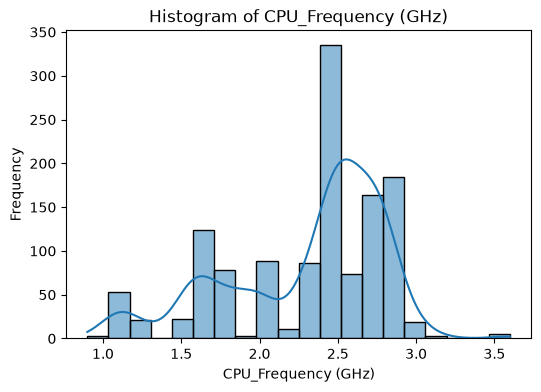

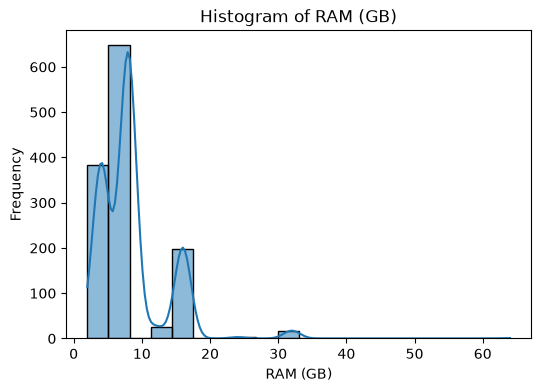

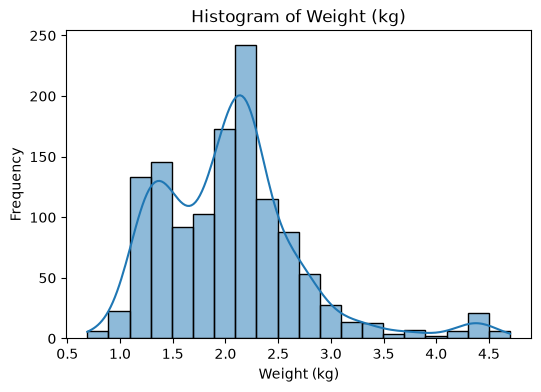

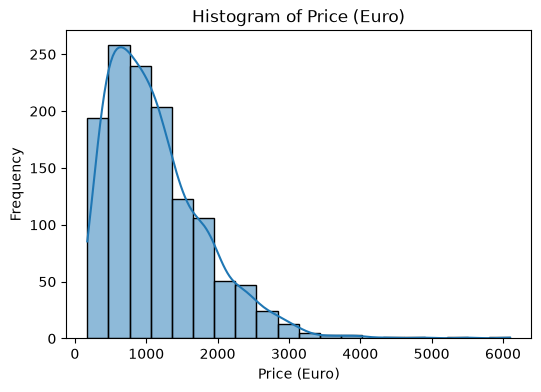

In [4]:
# Important numeric columns
numeric_columns = [
    "Inches",
    "CPU_Frequency (GHz)",
    "RAM (GB)",
    "Weight (kg)",
    "Price (Euro)"
]

# Plot histogram for each numeric column
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, bins=20, kde=True)

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

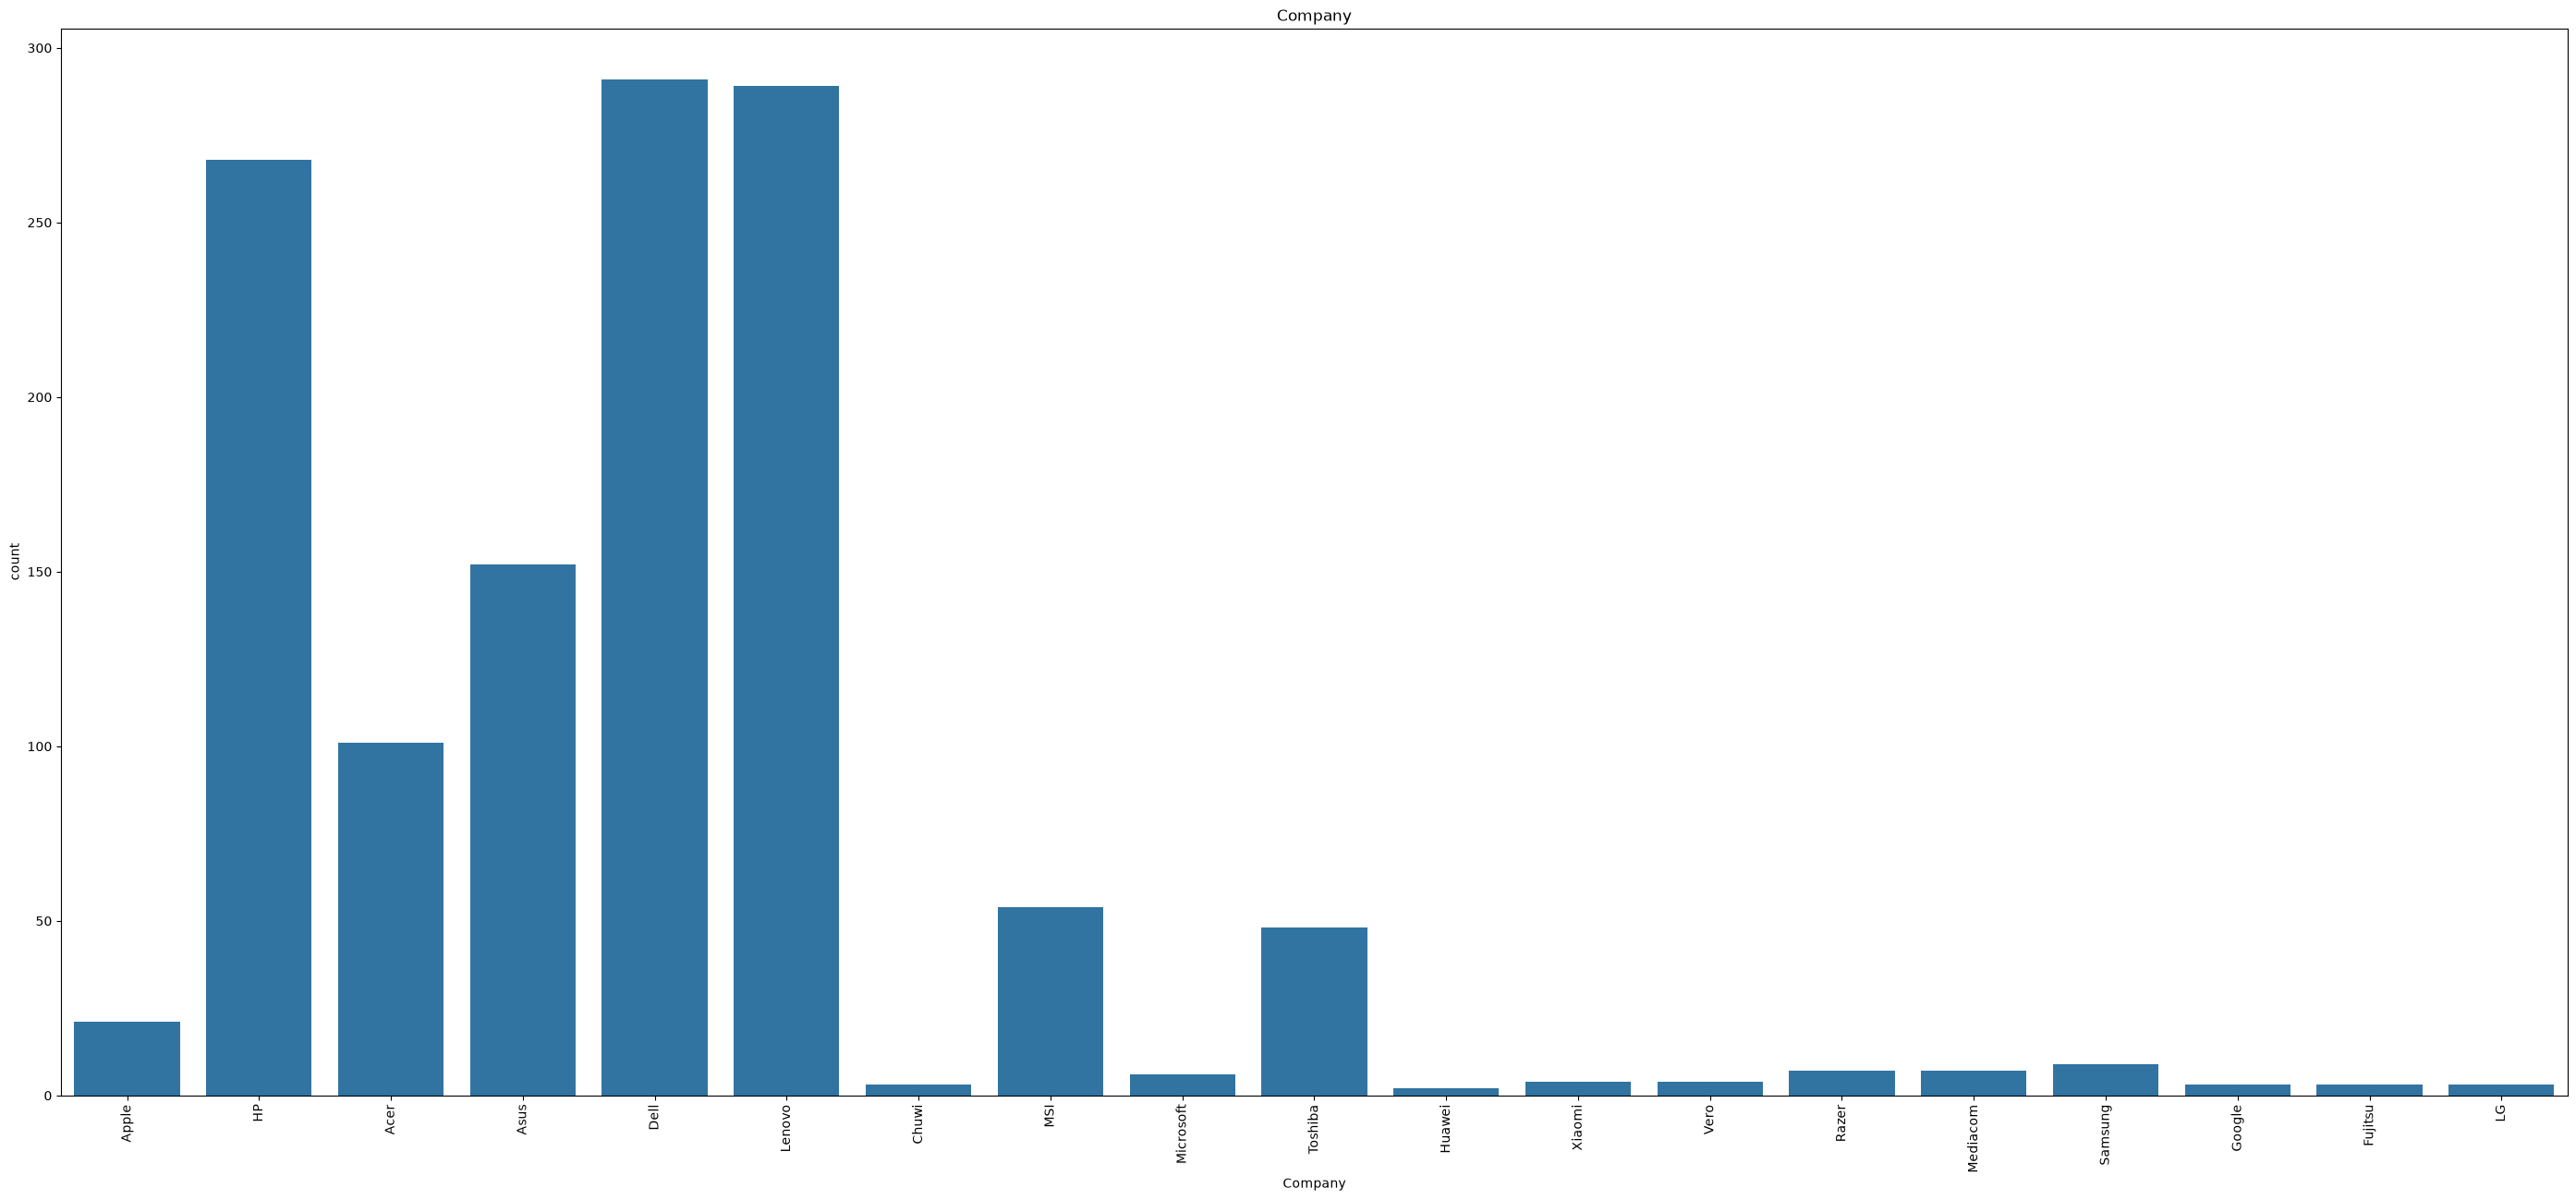

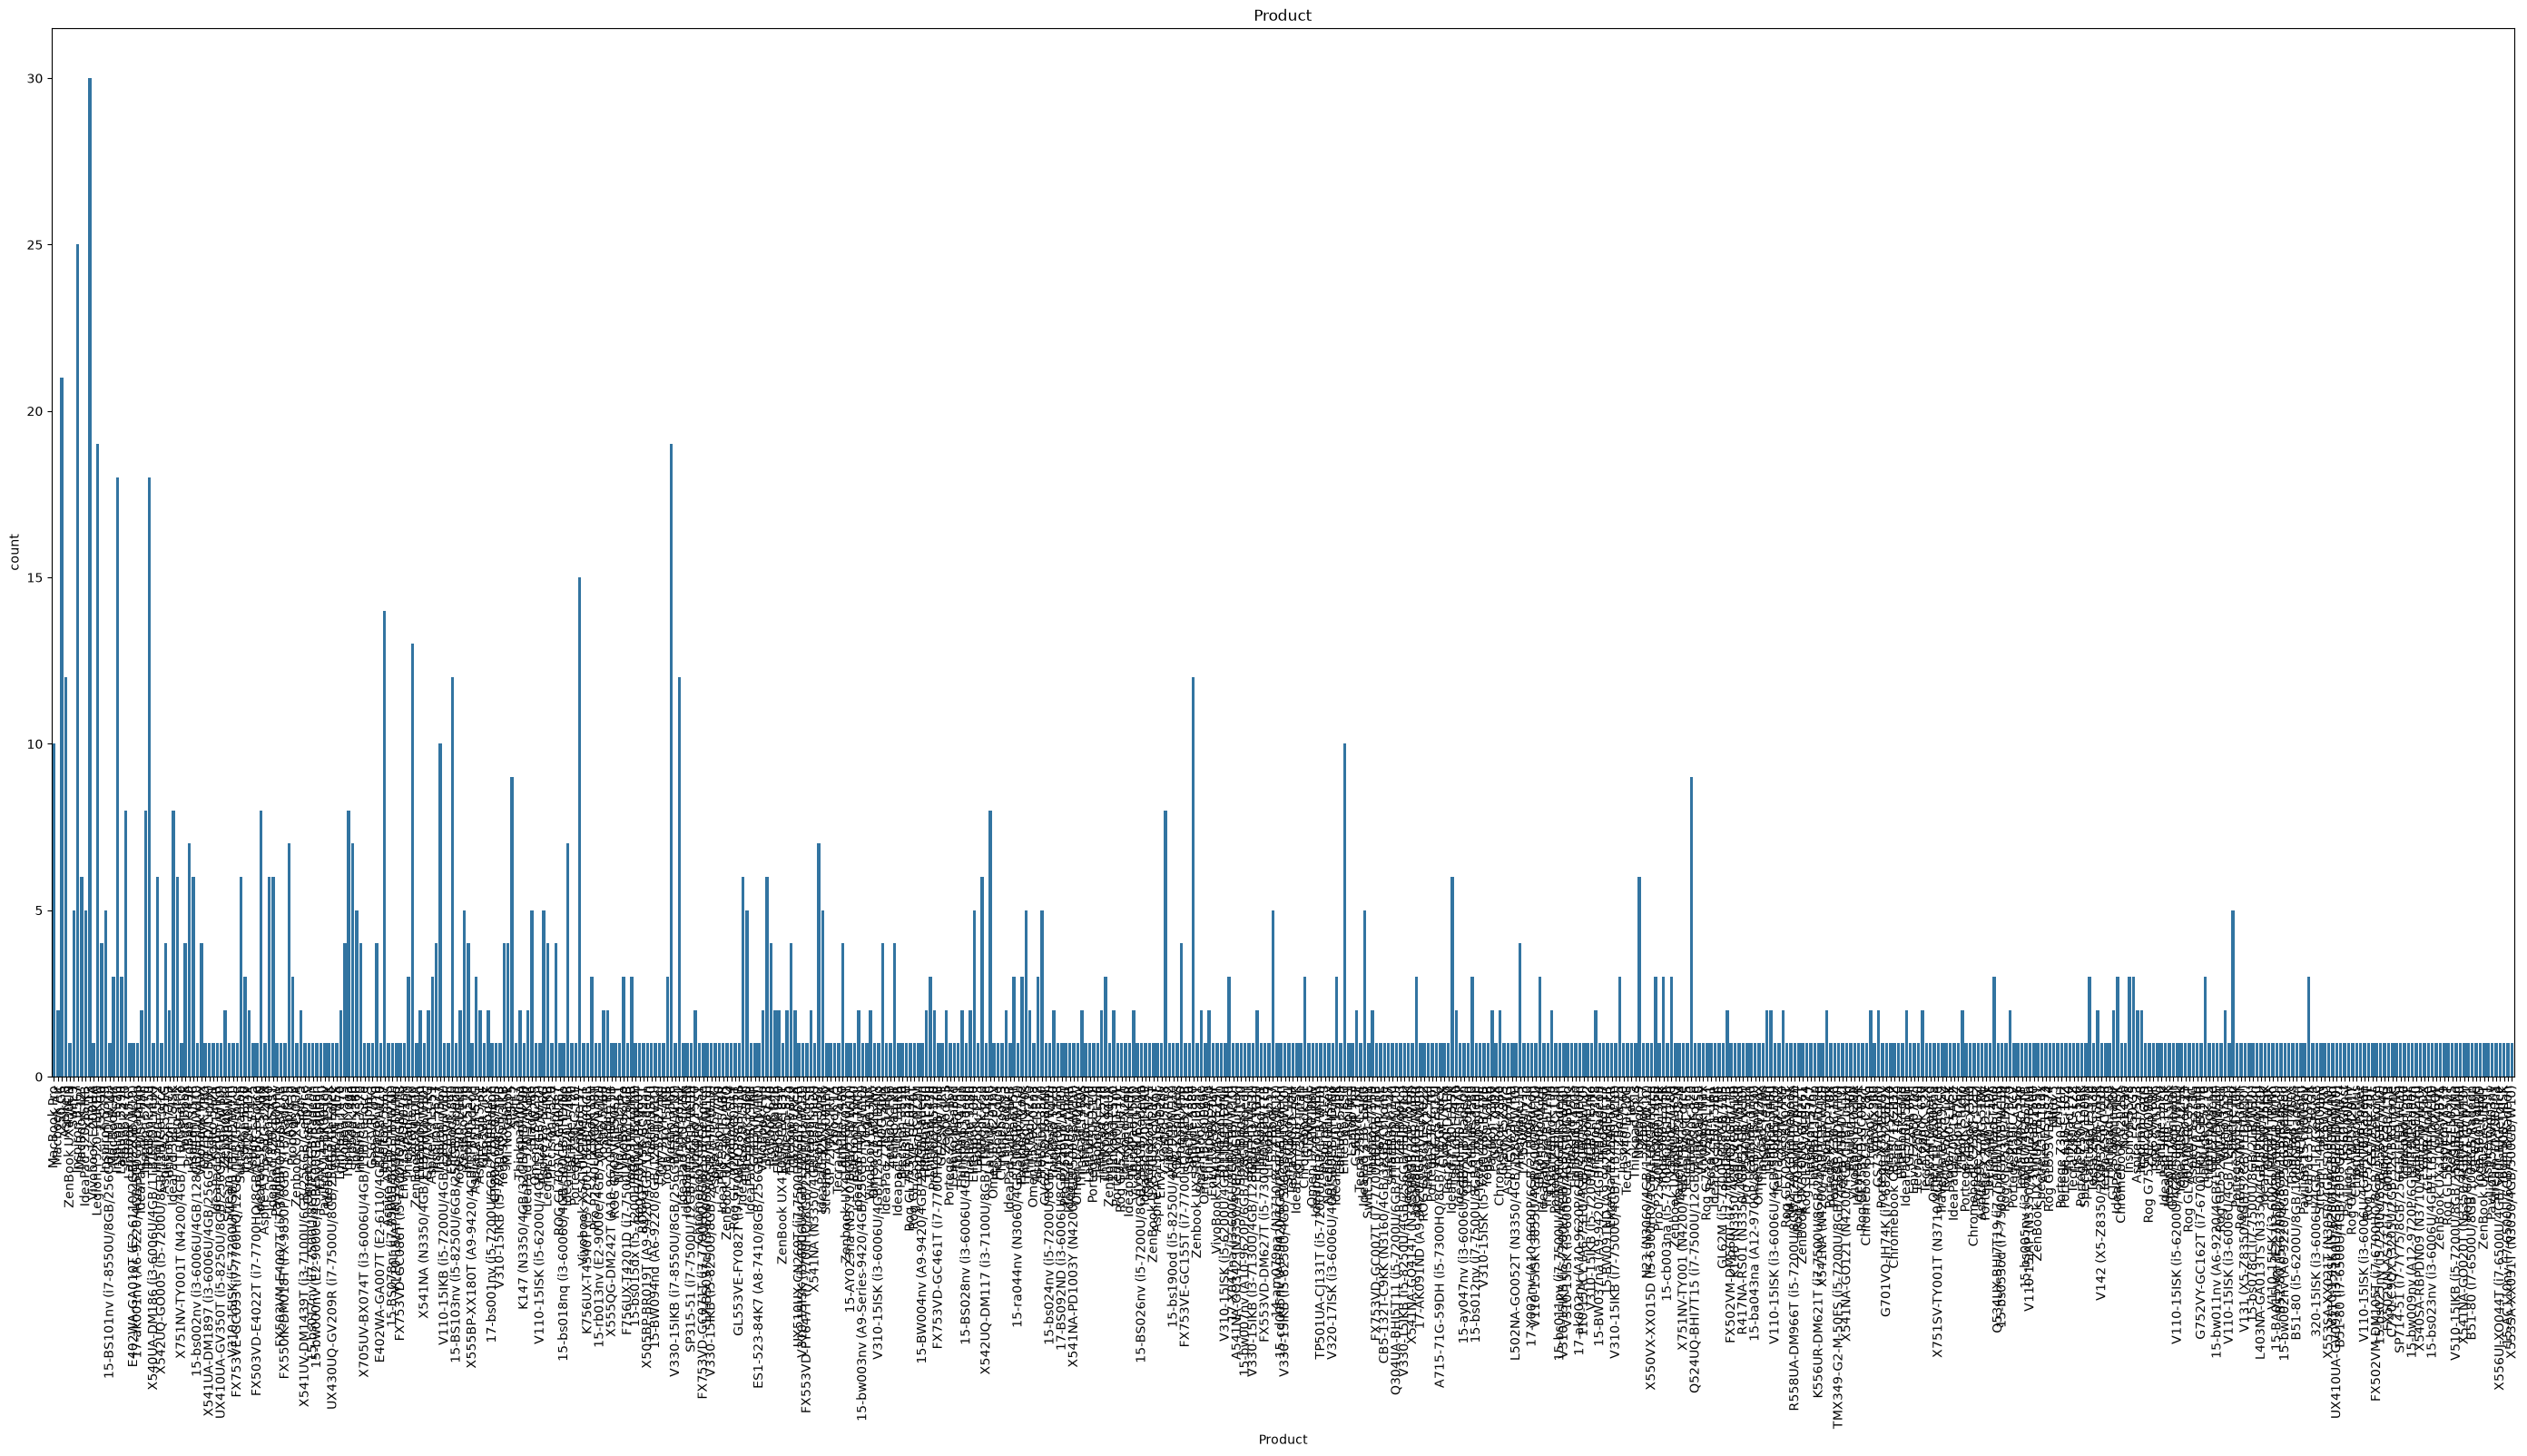

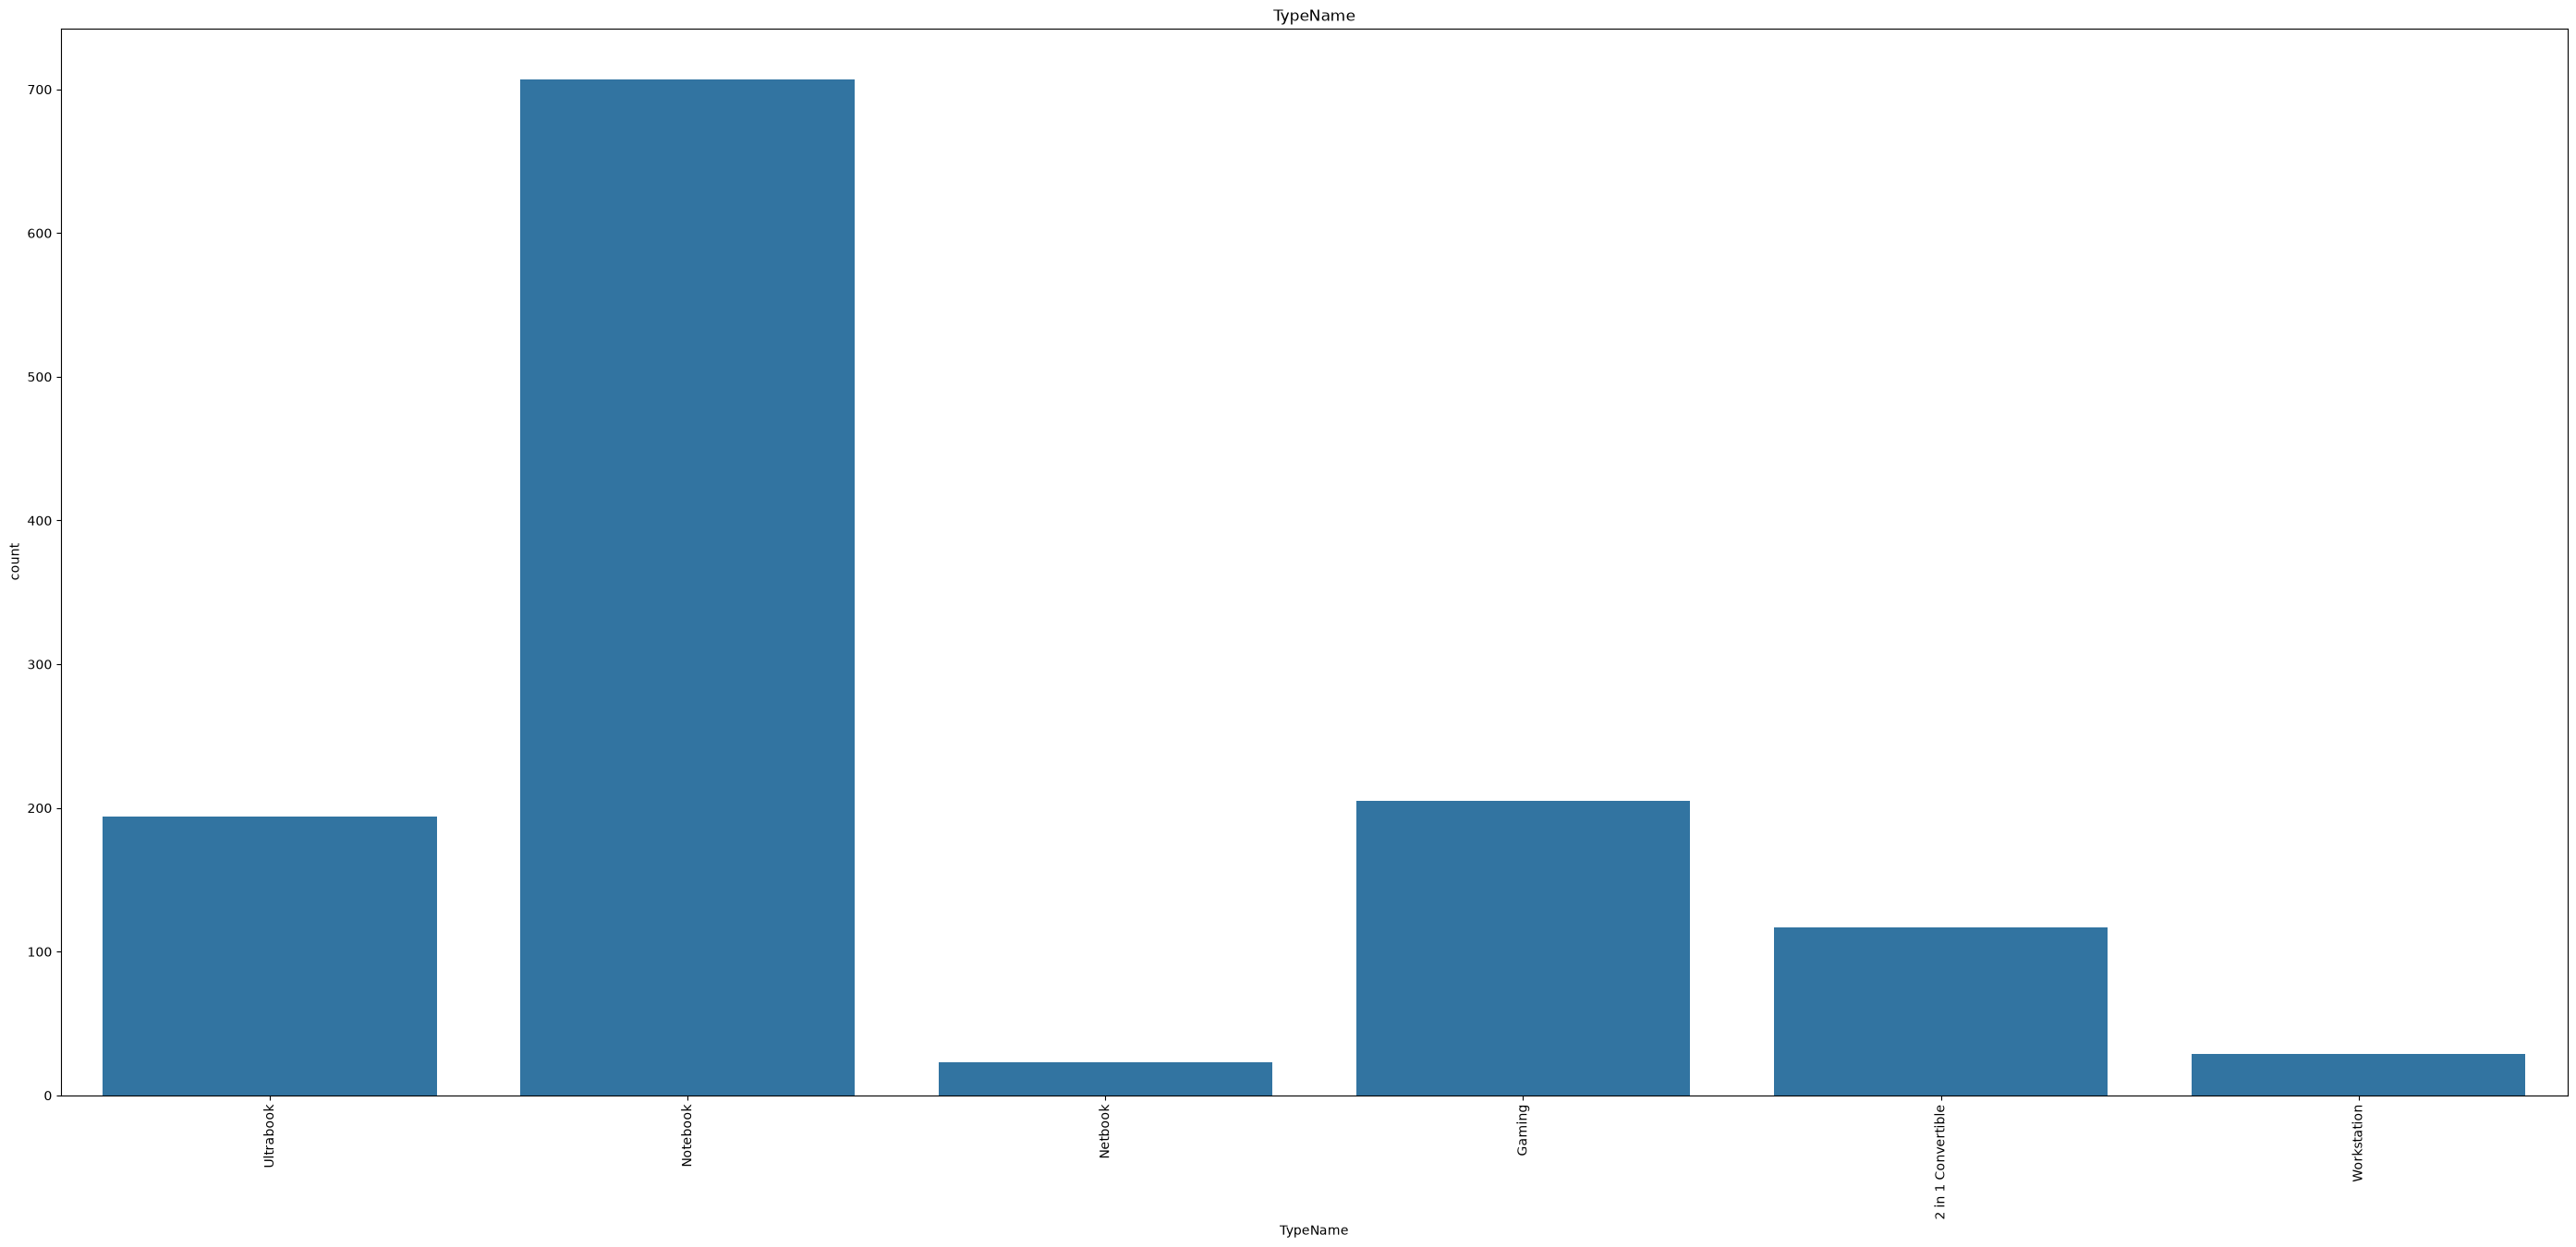

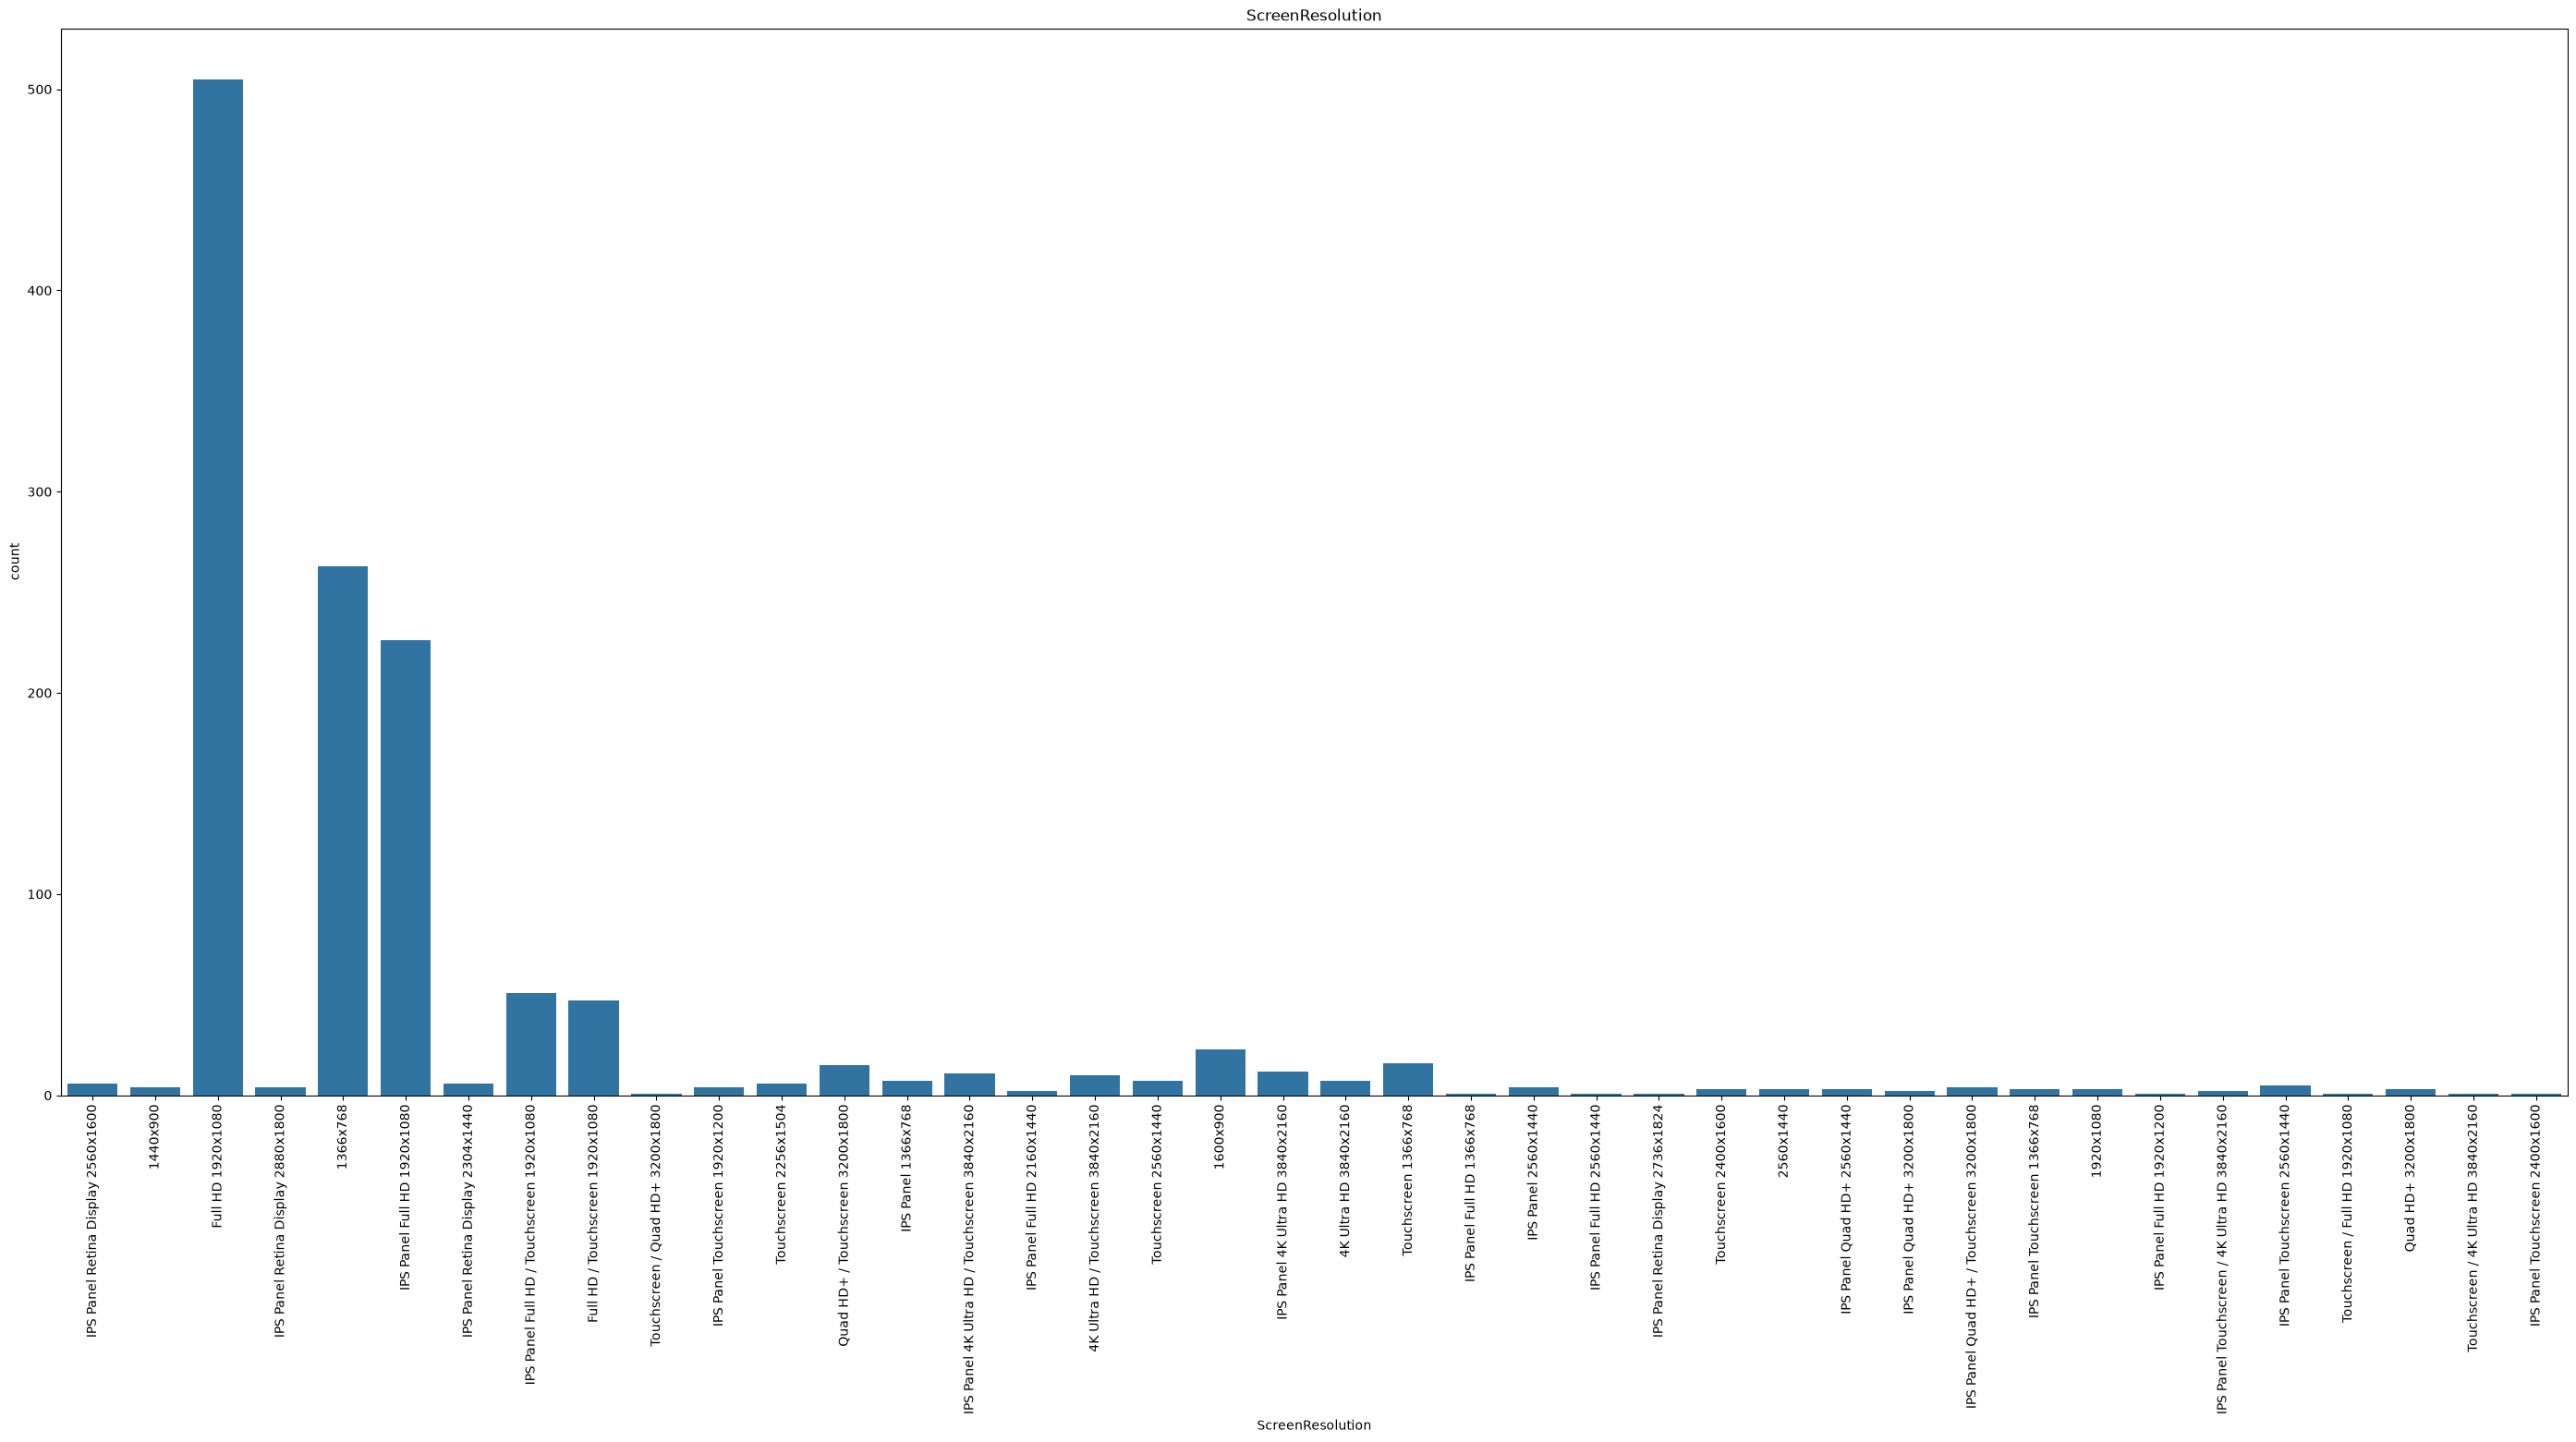

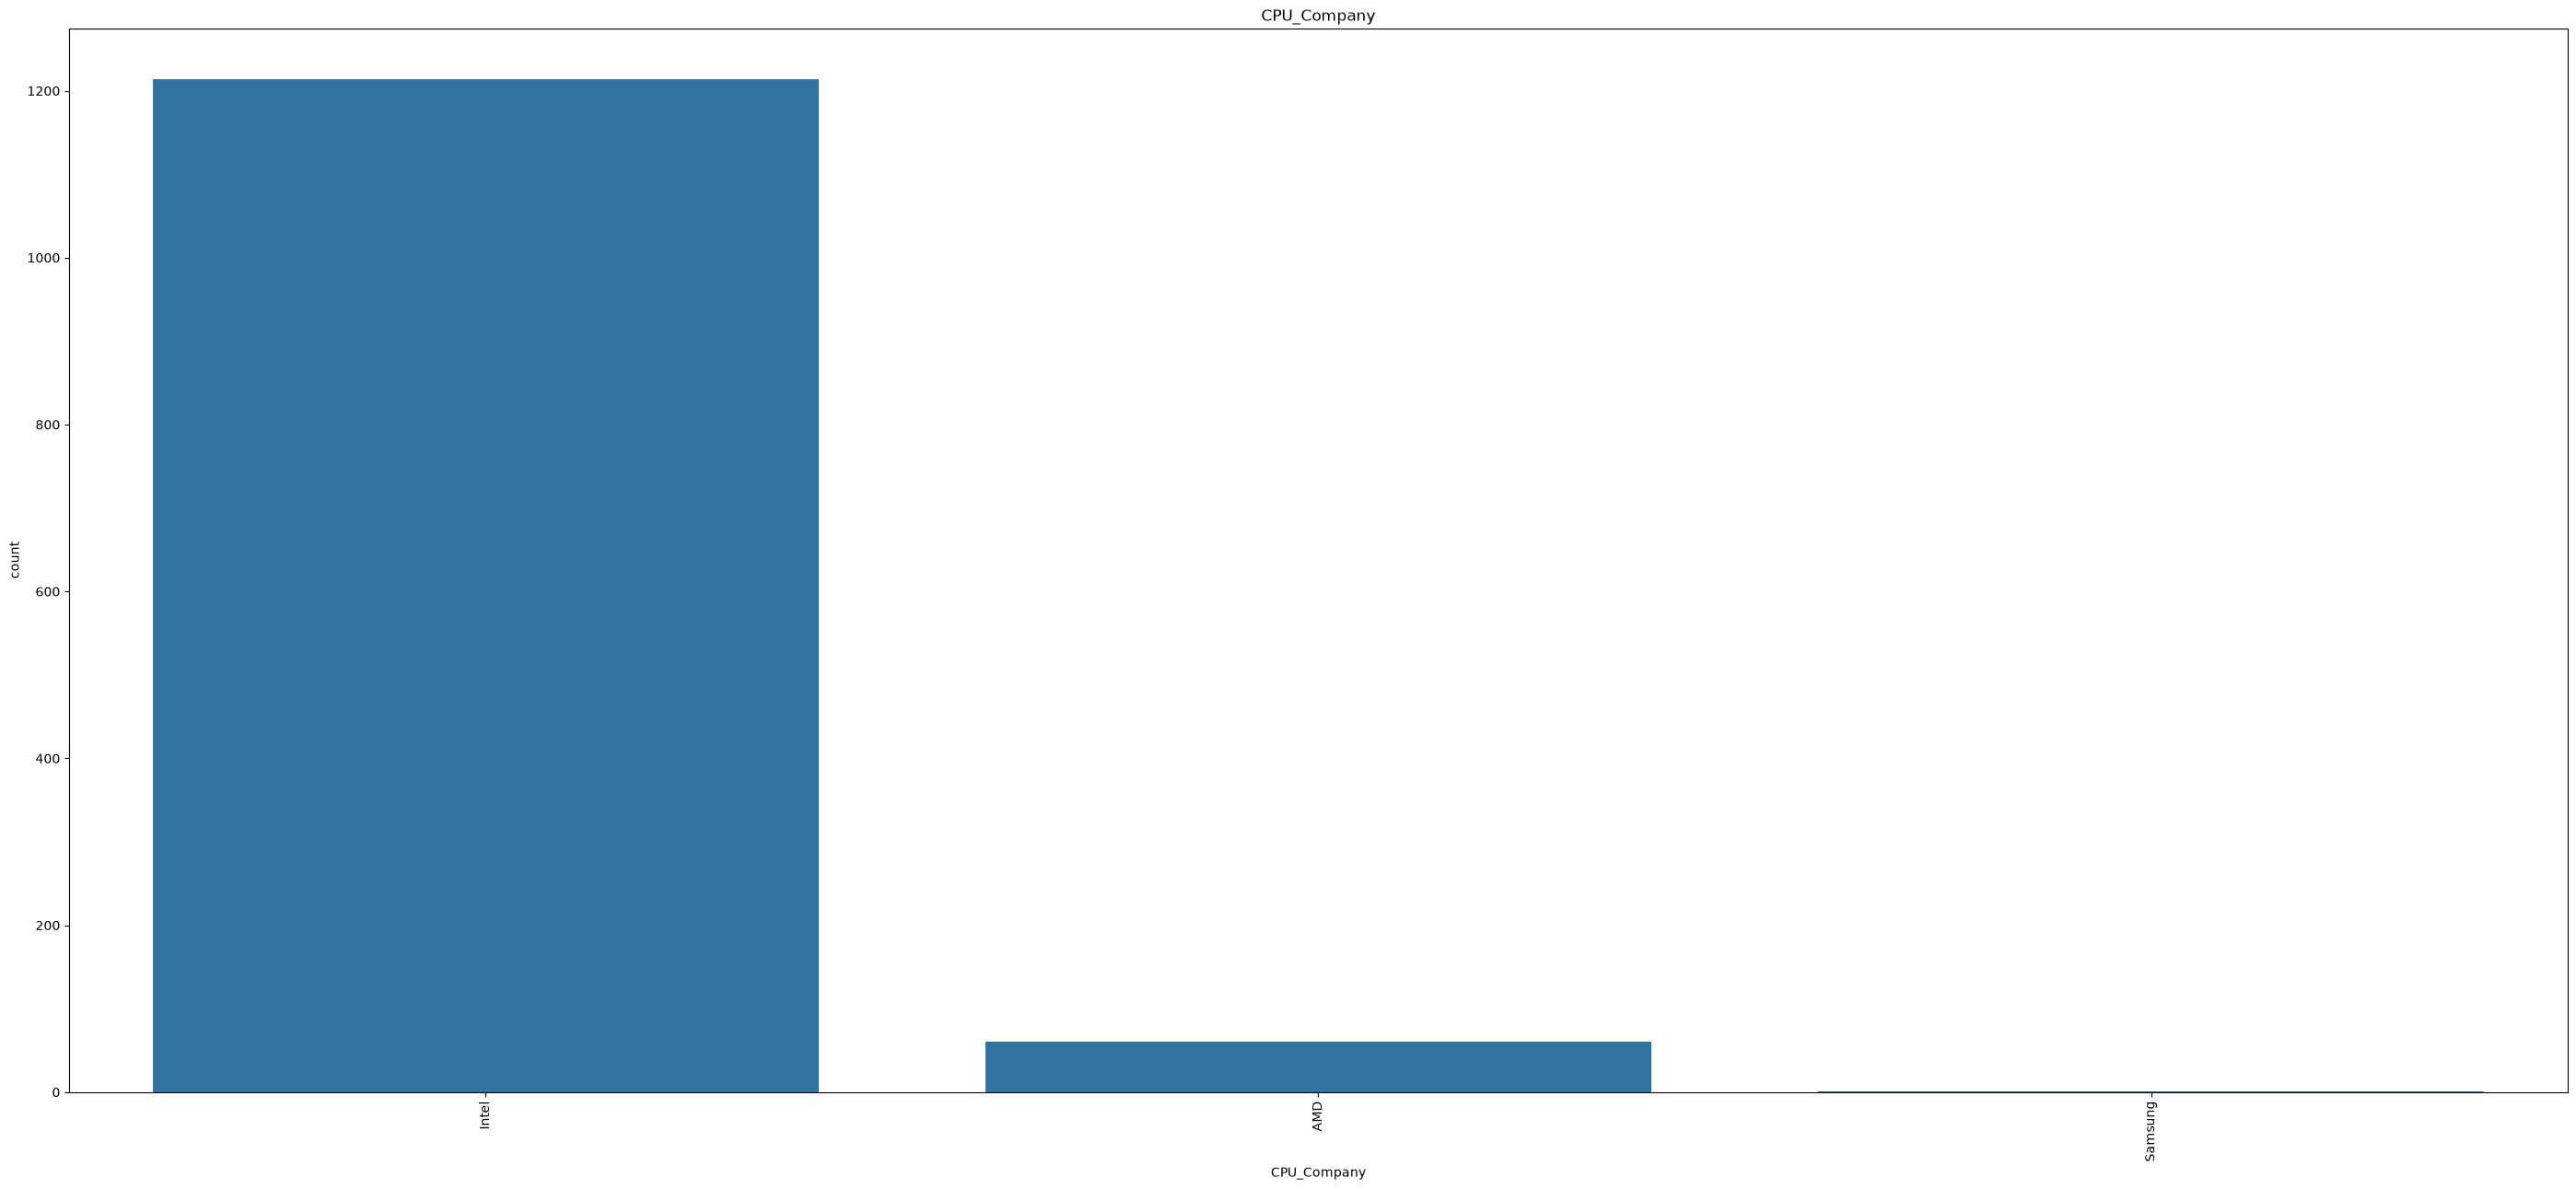

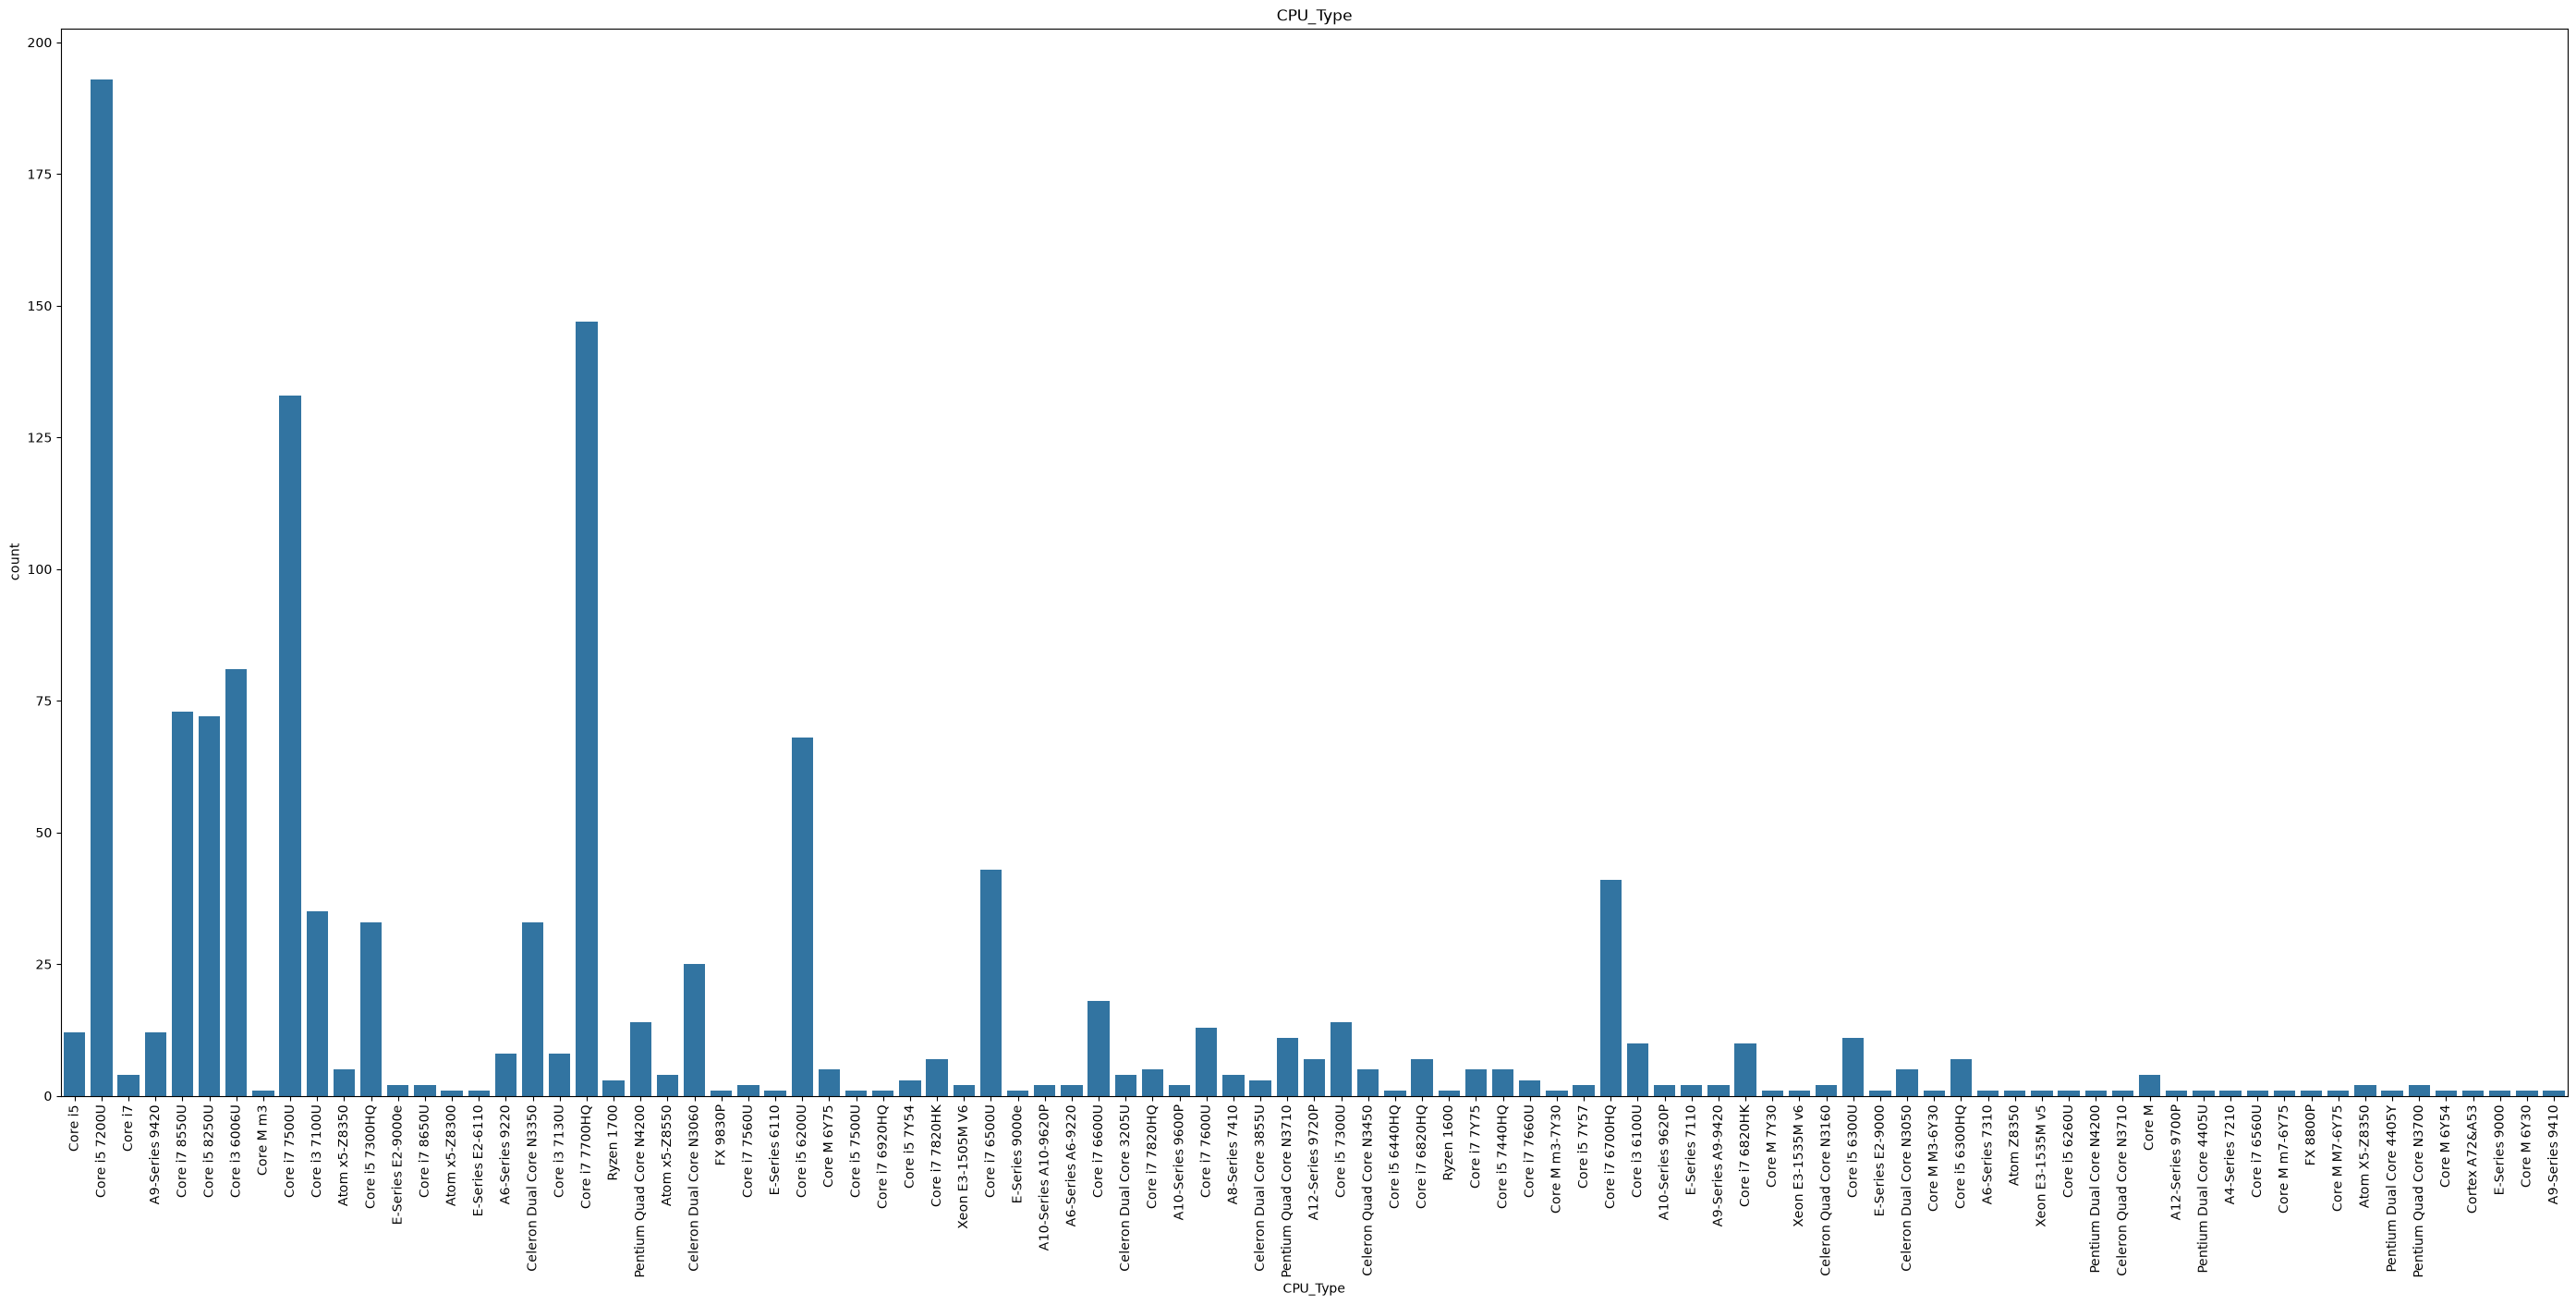

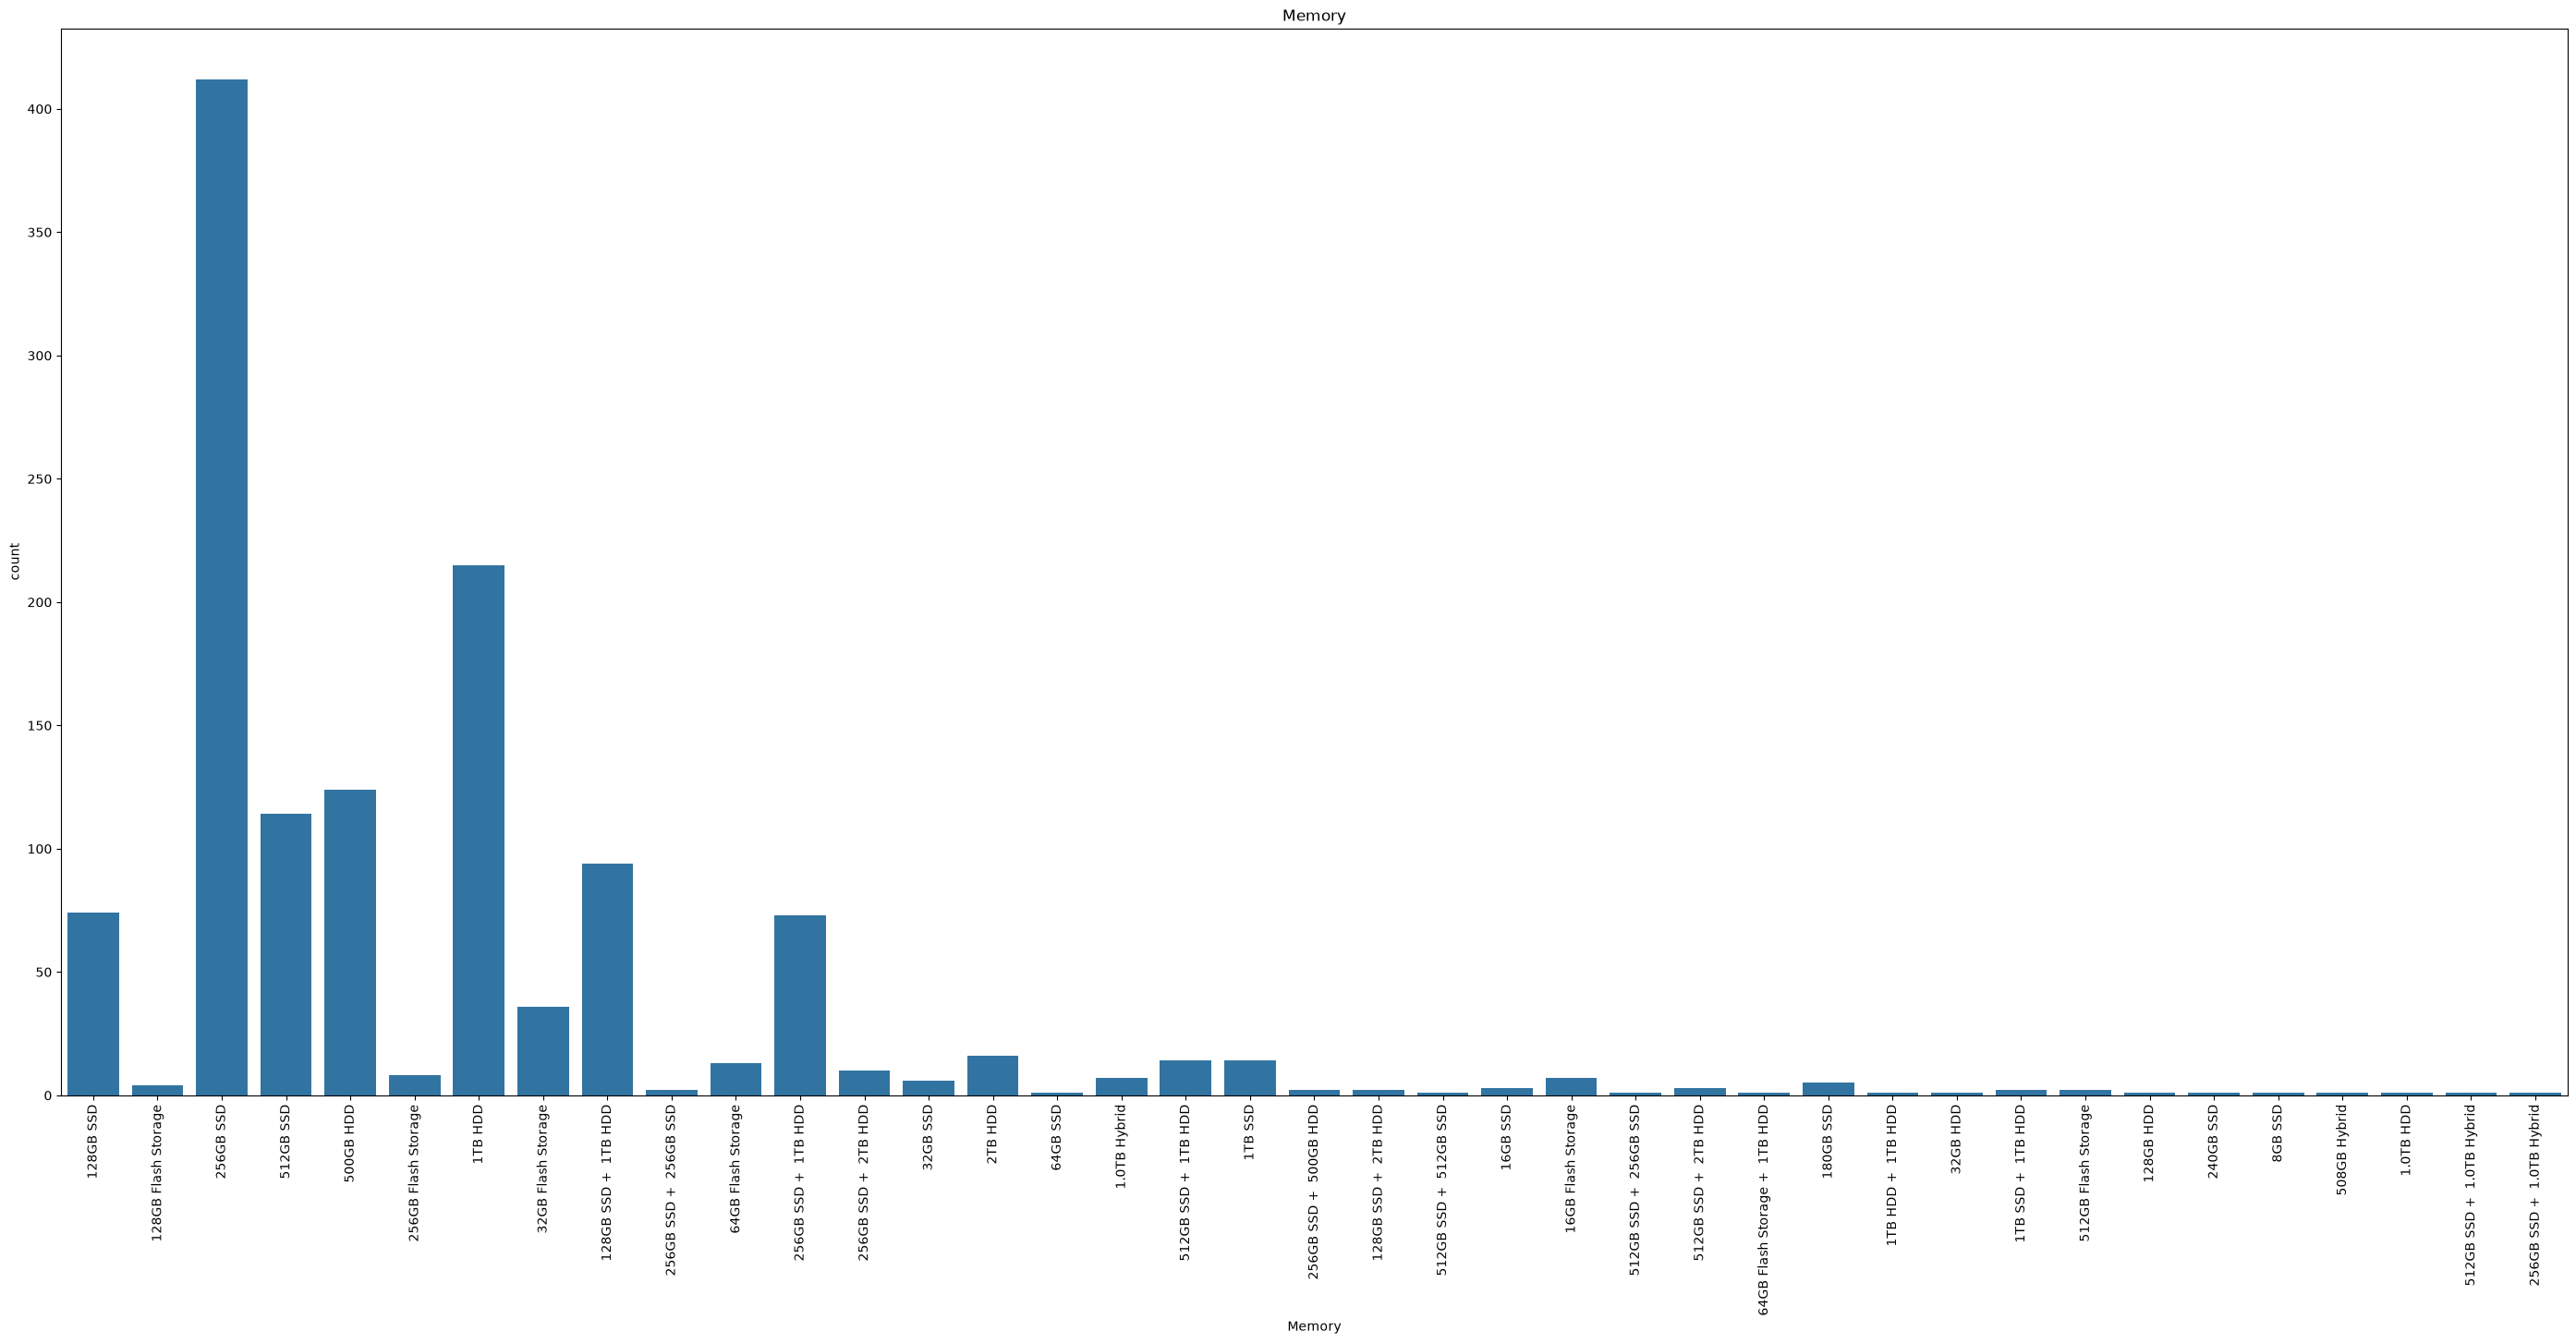

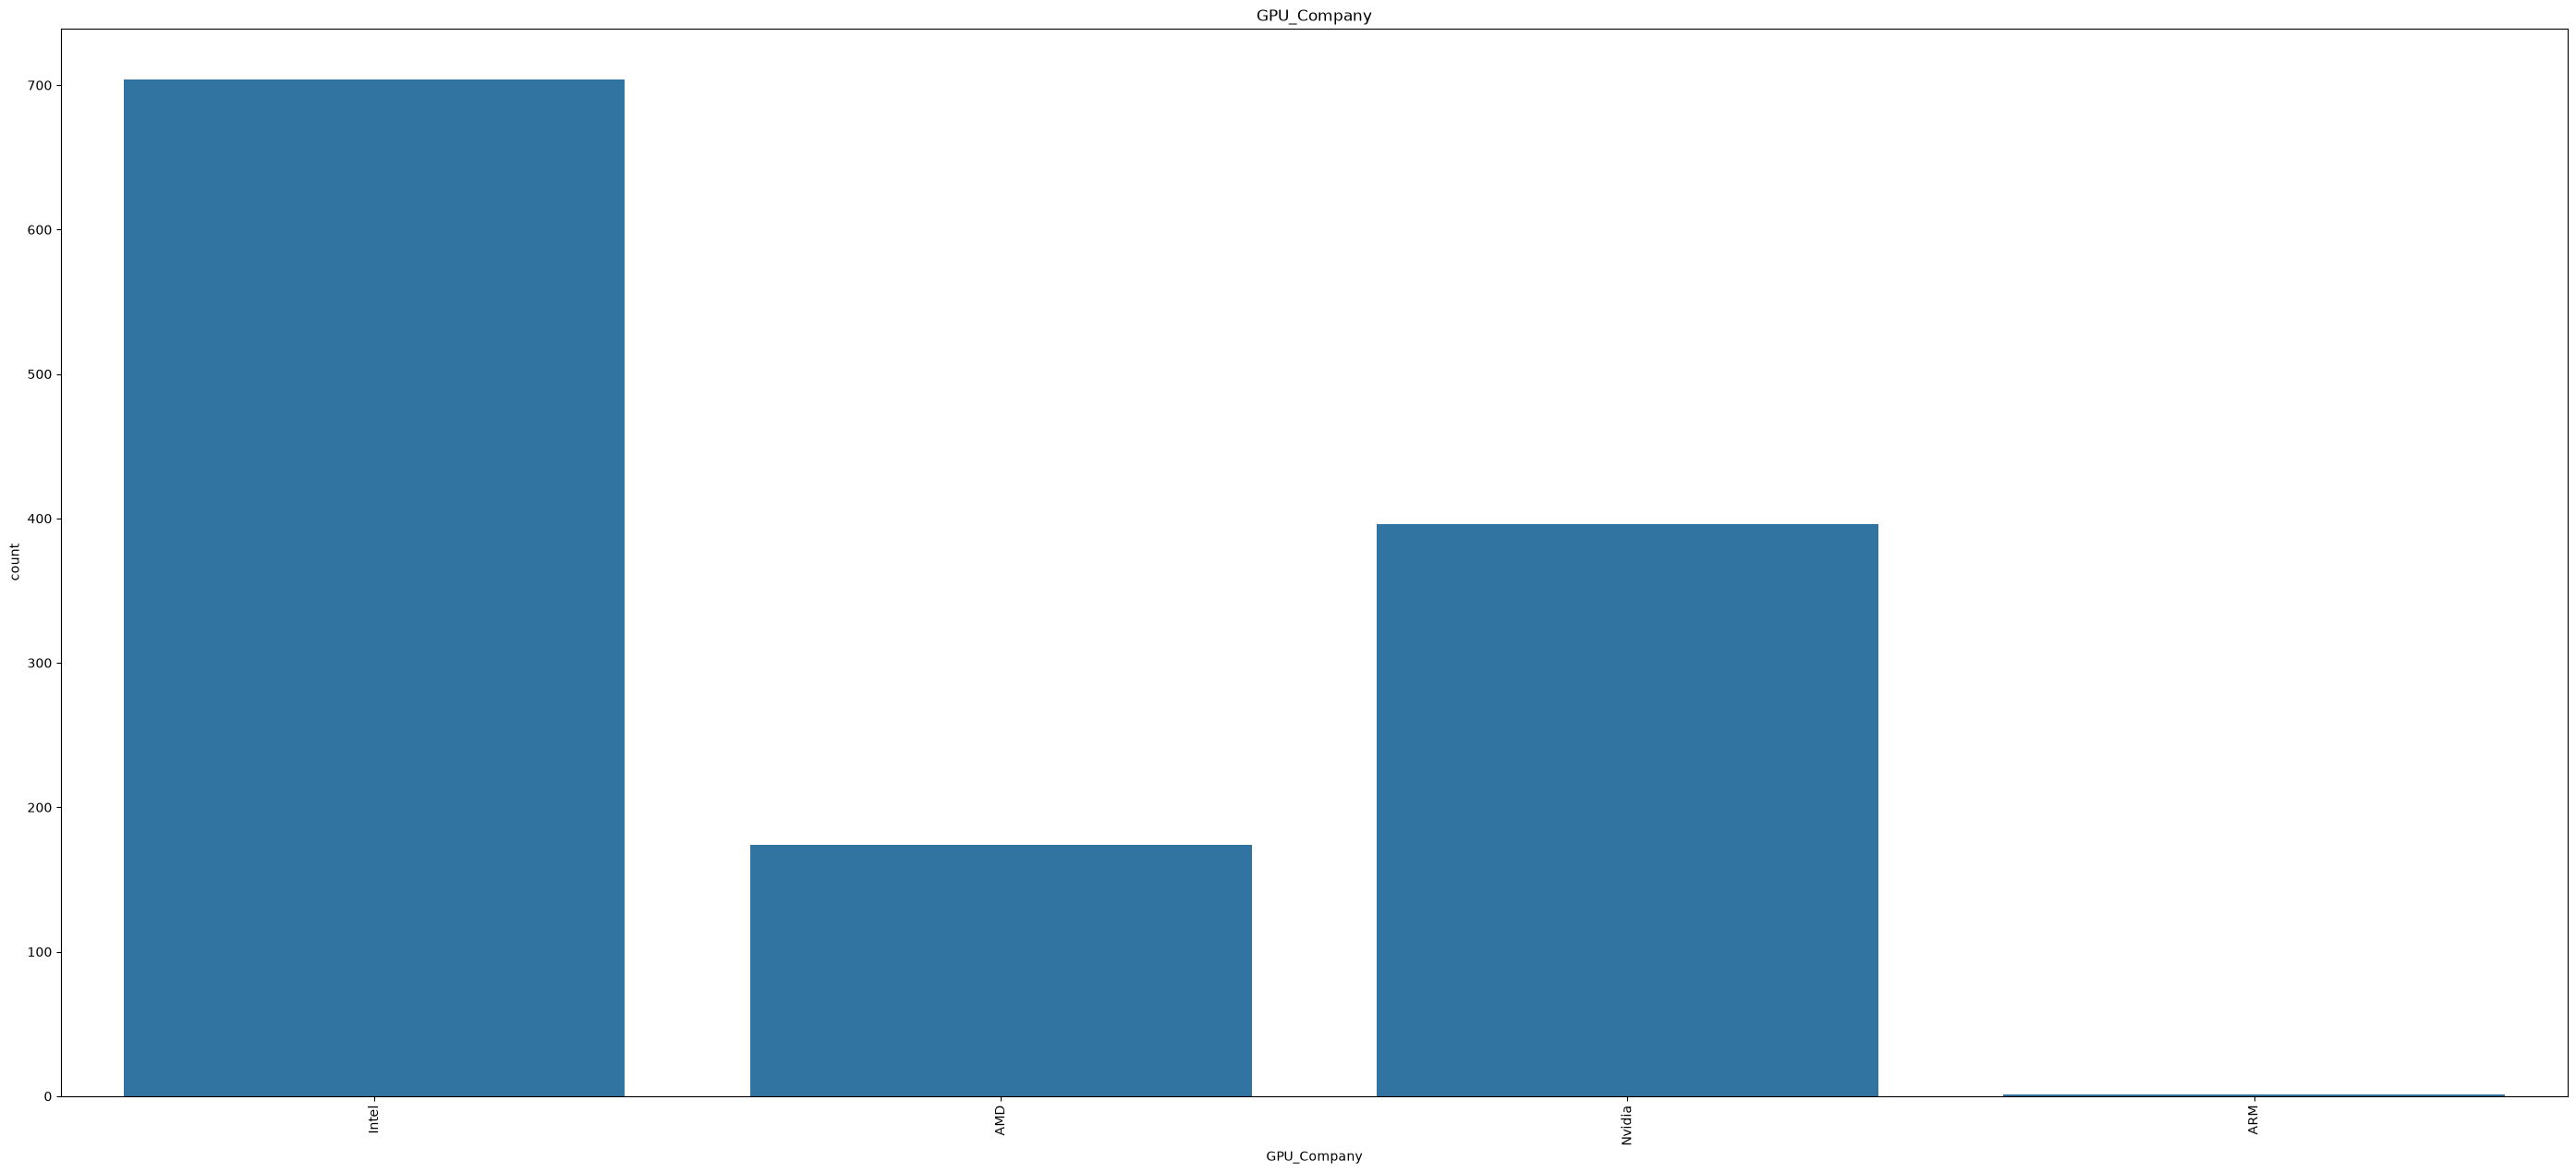

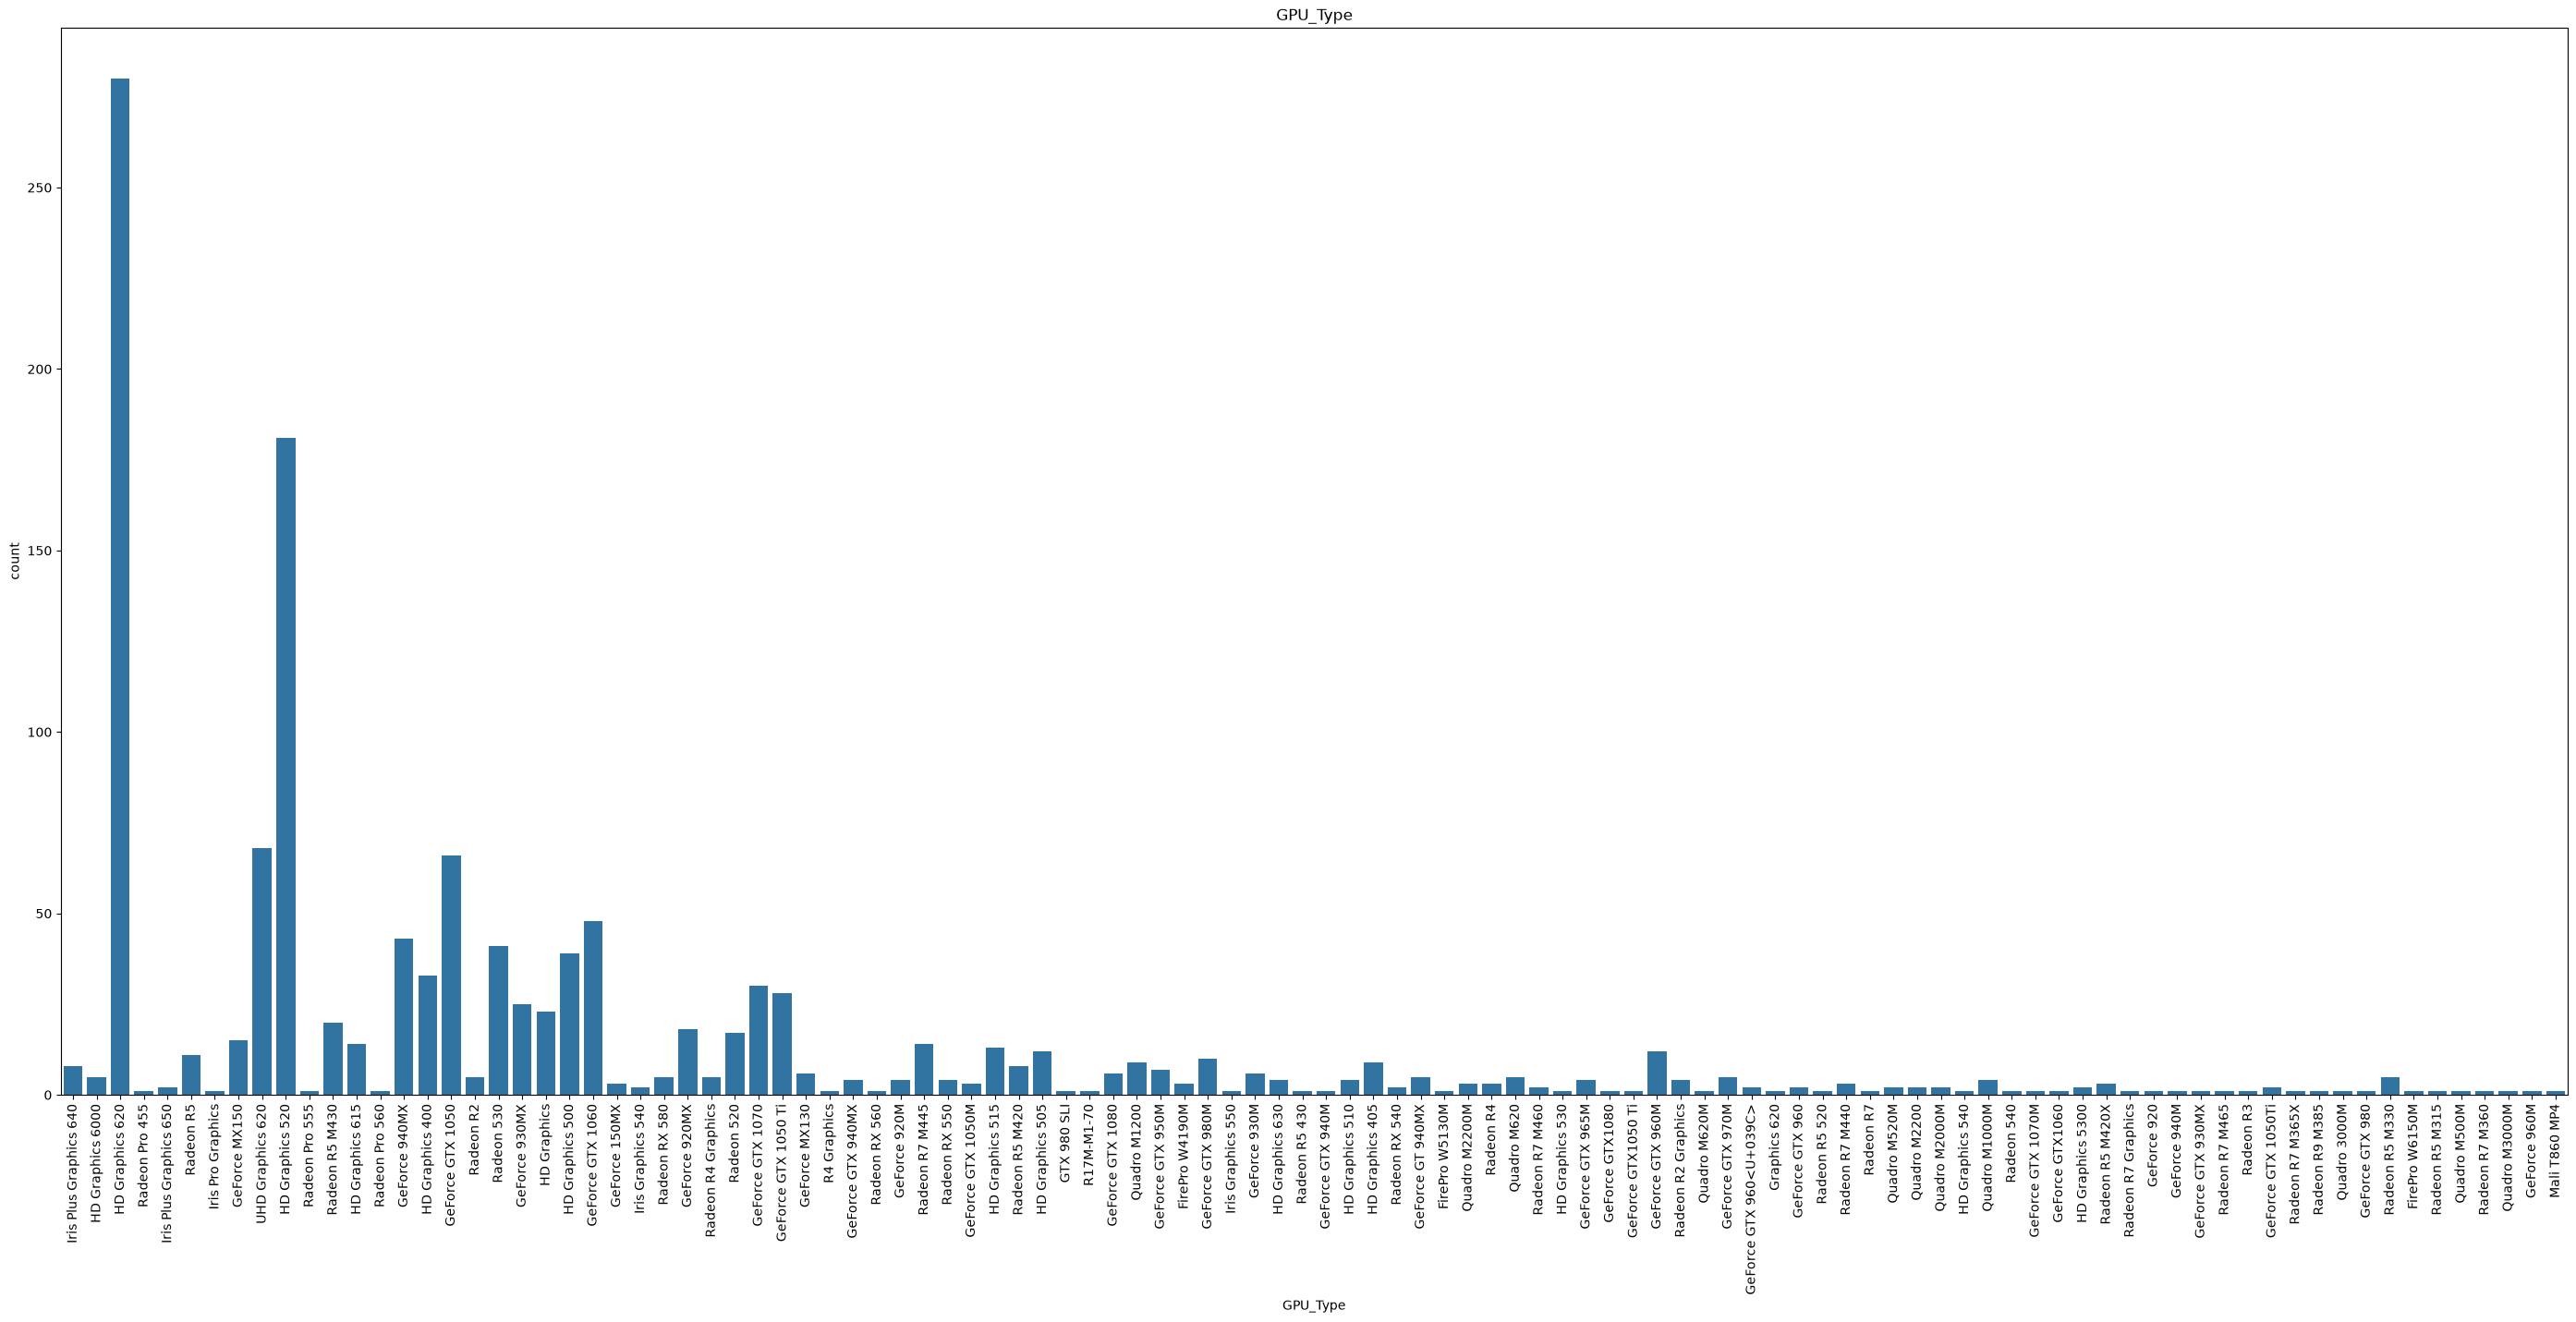

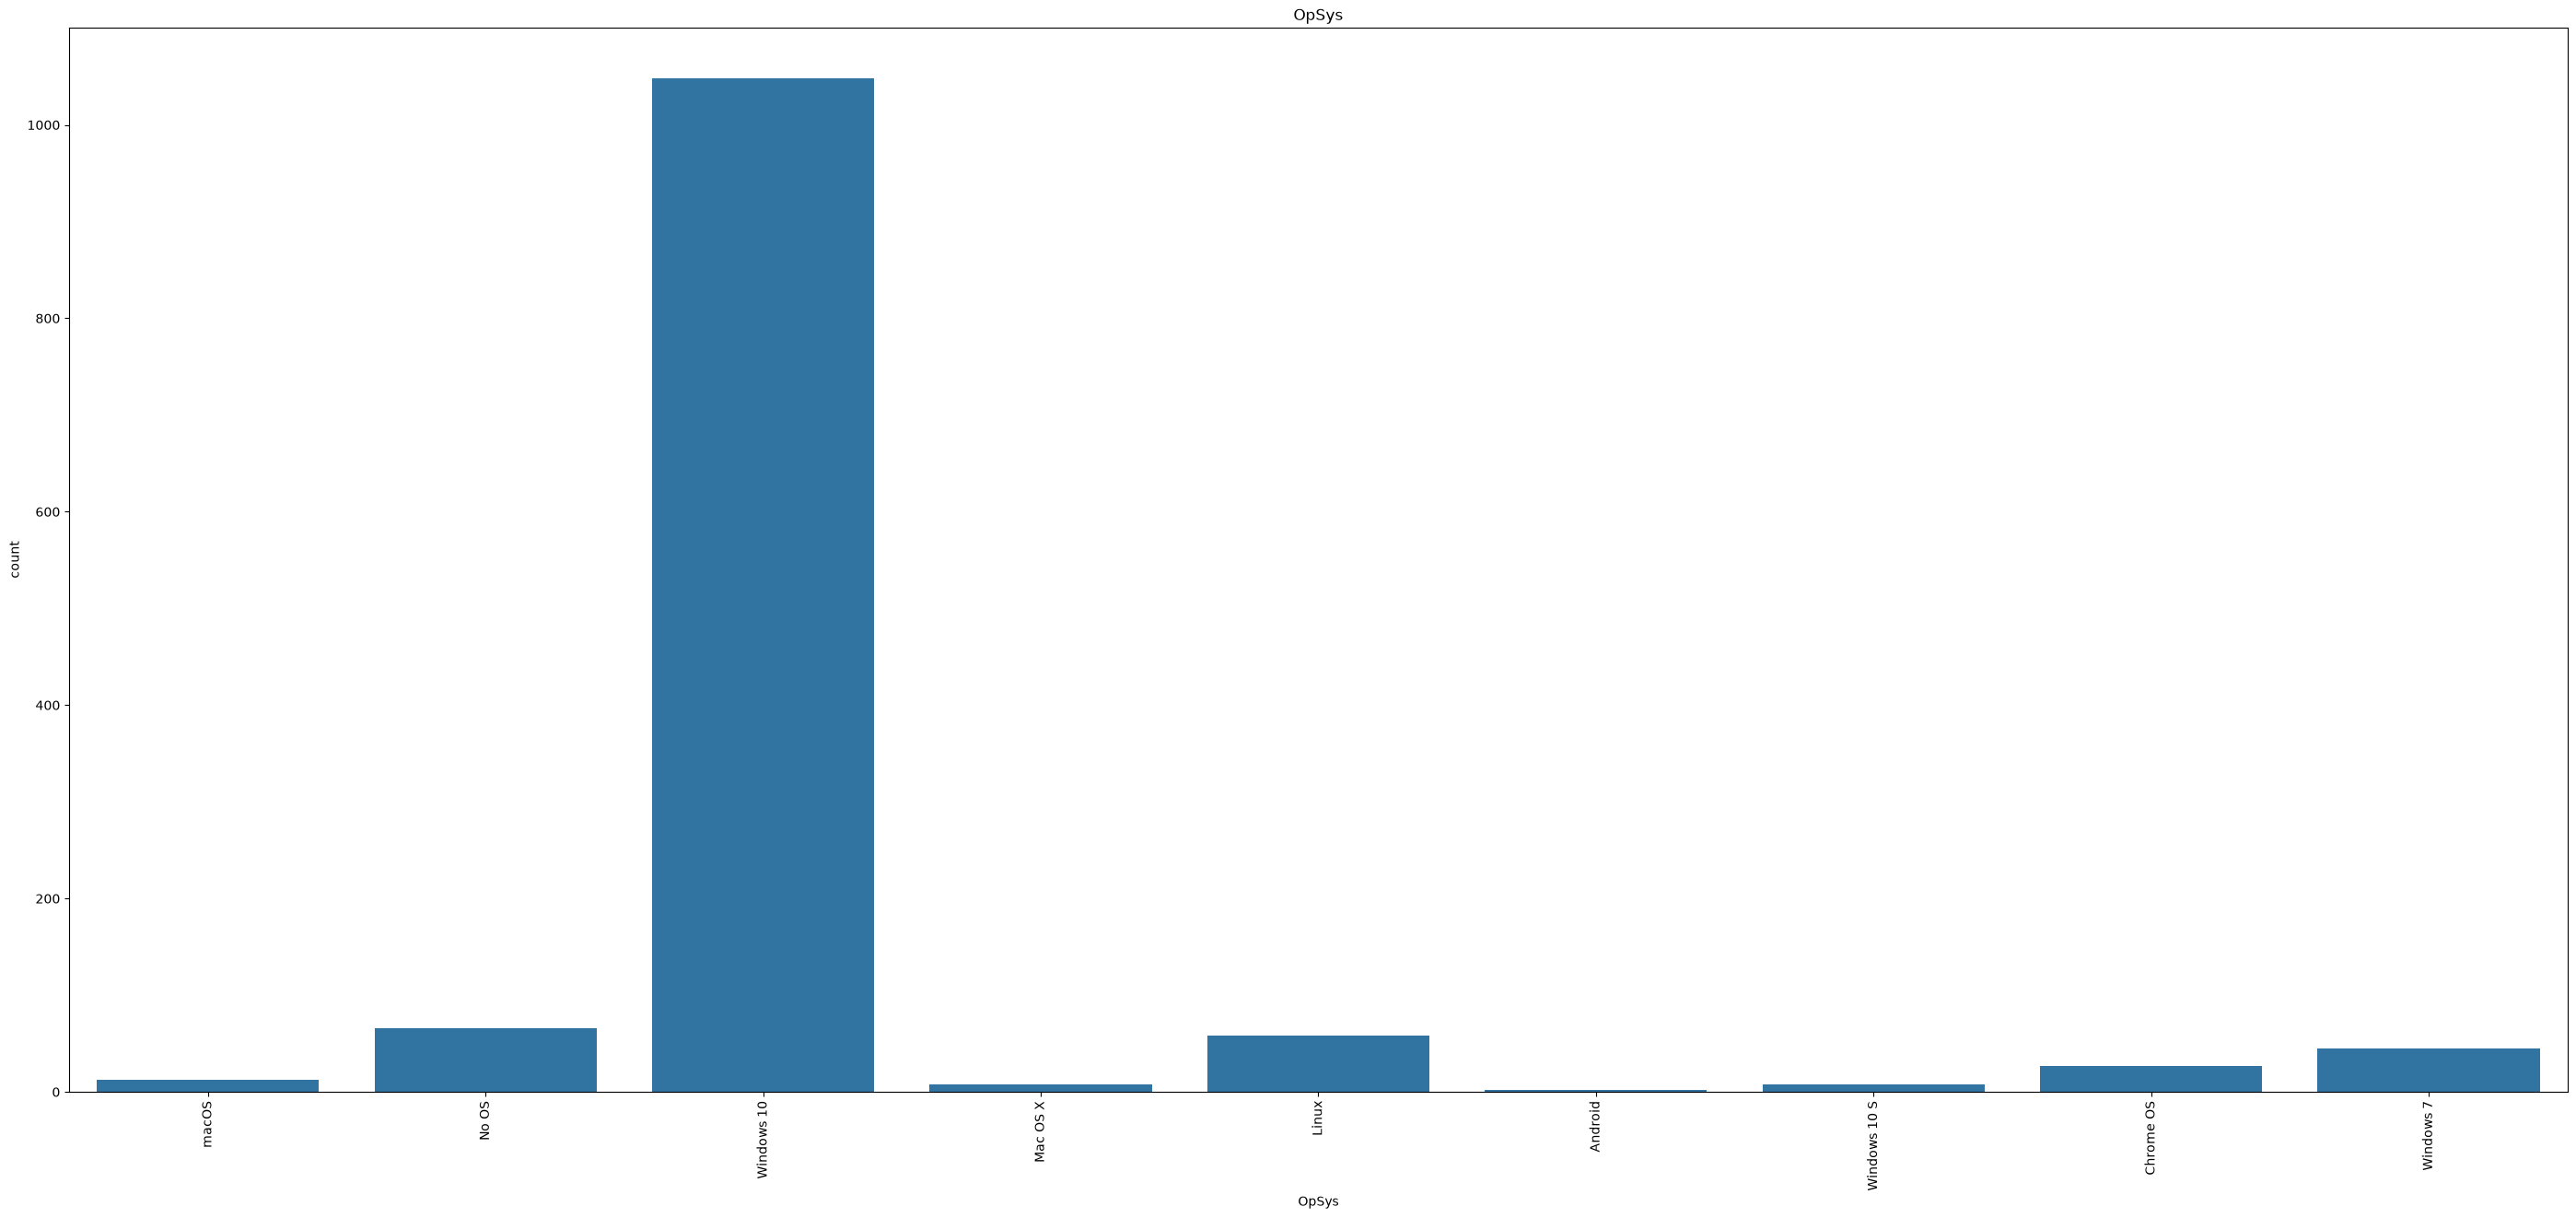

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = df.select_dtypes(include="str").columns

for col in cat_cols:
    plt.figure(figsize=(35,15))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=90)
    plt.title(col)
    plt.show()

#Business Insights:
# Company
#  HP, Dell, Lenovo, and Asus have the largest number of laptops.
# TypeName
#  Notebook and Ultrabook categories dominate the dataset.
# CPU Company
#  Intel processors are much more common than AMD.
# GPU Company
#  Intel graphics are widely used in budget laptops.
# Operating System
#  Windows is the most popular operating system.
# Memory
#  SSD-based storage is becoming more common than HDD.

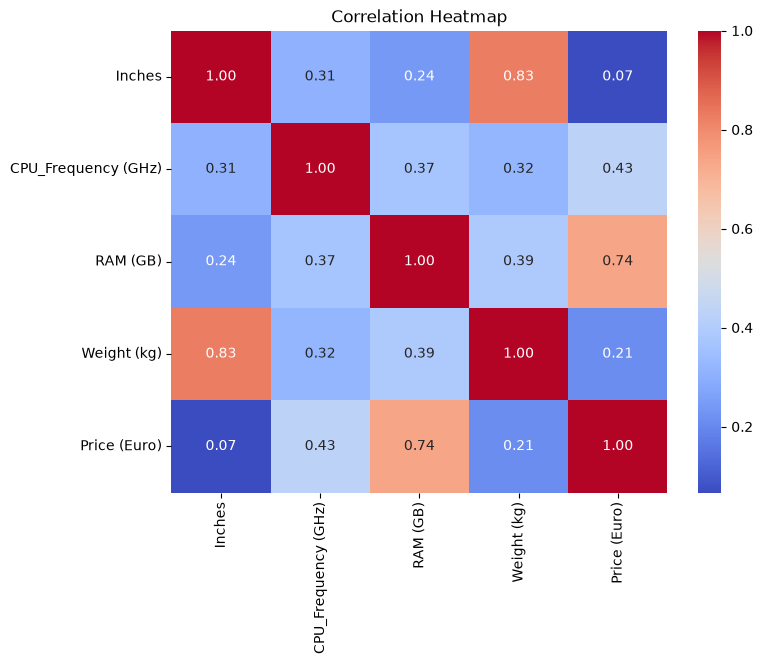

Correlation of all numeric features with Price (Euro):
Price (Euro)           1.000000
RAM (GB)               0.740287
CPU_Frequency (GHz)    0.428847
Weight (kg)            0.211883
Inches                 0.066608
Name: Price (Euro), dtype: float64


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# Correlation with target variable
price_corr = corr_matrix["Price (Euro)"].sort_values(ascending=False)

print("Correlation of all numeric features with Price (Euro):")
print(price_corr)

# Observations:
# RAM has a strong positive correlation with laptop price.
# CPU Frequency is positively correlated with price.
# Weight has a moderate correlation with price.
# Screen size (Inches) has a weaker relationship with price.

In [7]:
# Independent Features
X = df.drop("Price (Euro)", axis=1)

# Dependent Feature
y = df["Price (Euro)"]

print("Independent Features")
print(X.columns)

print("\nDependent Feature")
print(y.name)

# Justification:
# Independent Features (X):
# All laptop specifications such as Company, RAM, CPU, GPU, Weight, Memory, Screen Size, etc.
# Dependent Feature (y):
# Price (Euro)
# Reason: The objective is to predict laptop price using laptop specifications.

Independent Features
Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
       'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory',
       'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)'],
      dtype='str')

Dependent Feature
Price (Euro)


In [10]:
# Before Encoding
print("Before Encoding:")
print(df[["Company","TypeName"]].head())

# One Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# After Encoding
print("\nAfter Encoding:")
print(df_encoded.head())

# Explanation:
# One-Hot Encoding converts categorical values into binary (0 and 1) columns. 
# It prevents the model from assuming an incorrect order among categories.
# drop_first=True is used to reduce multicollinearity.

Before Encoding:
  Company   TypeName
0   Apple  Ultrabook
1   Apple  Ultrabook
2      HP   Notebook
3   Apple  Ultrabook
4   Apple  Ultrabook

After Encoding:
   Inches  CPU_Frequency (GHz)  RAM (GB)  Weight (kg)  Price (Euro)  \
0    13.3                  2.3         8         1.37       1339.69   
1    13.3                  1.8         8         1.34        898.94   
2    15.6                  2.5         8         1.86        575.00   
3    15.4                  2.7        16         1.83       2537.45   
4    13.3                  3.1         8         1.37       1803.60   

   Company_Apple  Company_Asus  Company_Chuwi  Company_Dell  Company_Fujitsu  \
0           True         False          False         False            False   
1           True         False          False         False            False   
2          False         False          False         False            False   
3           True         False          False         False            False   
4           T

In [9]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop("Price (Euro)", axis=1)
y = df_encoded["Price (Euro)"]

# Standard Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

     Inches  CPU_Frequency (GHz)  RAM (GB)  Weight (kg)  Company_Apple  \
0 -1.205746            -0.005918 -0.086499    -1.002380       7.727502   
1 -1.205746            -0.998674 -0.086499    -1.047227       7.727502   
2  0.403873             0.391185 -0.086499    -0.269871      -0.129408   
3  0.263906             0.788288  1.483418    -0.314718       7.727502   
4 -1.205746             1.582493 -0.086499    -1.002380       7.727502   

   Company_Asus  Company_Chuwi  Company_Dell  Company_Fujitsu  Company_Google  \
0     -0.367902      -0.048564     -0.543812        -0.048564       -0.048564   
1     -0.367902      -0.048564     -0.543812        -0.048564       -0.048564   
2     -0.367902      -0.048564     -0.543812        -0.048564       -0.048564   
3     -0.367902      -0.048564     -0.543812        -0.048564       -0.048564   
4     -0.367902      -0.048564     -0.543812        -0.048564       -0.048564   

   ...  GPU_Type_Radeon RX 580  GPU_Type_UHD Graphics 620  OpSys_Chr